# 00_08 — Regresión PSBP sobre scores FPCA: verificación de convergencia

**Objetivo:** Modelar la dinámica temporal de los scores FPCA mediante regresiones AR(1) con
modelo PSBP por componente, **estandarizando previamente las curvas funcionales** y
**verificando la convergencia del MCMC** mediante un conjunto completo de diagnósticos.

## Pipeline completo

```
FAR(1) simulado  ──►  X ∈ ℝ^{T×G}
       ↓
Estandarización por columna (z-score a lo largo de t para cada s_g)
       ↓
B-spline   ──►  Θ ∈ ℝ^{T×K}  
       ↓
Para cada componente k y cada cadena c=1..C:
    θ_{t,k} = α_k + β_k · θ_{t-1,k} + ε_{t,k}    (modelo PSBP_FD_v1)
       ↓
Diagnósticos de convergencia: trazas, ACF, ESS, Geweke, Gelman-Rubin R̂
       ↓
Evaluación: RMSE, P(γ=1), reconstrucción funcional
```

## Diferencias frente al `00_06`

| Aspecto | `00_06` | `00_07` |
|---------|---------|---------|
| Pre-procesamiento de X | sin estandarizar | z-score por columna |
| Núm. cadenas MCMC | 1 | C (≥2) para Gelman-Rubin |
| Diagnósticos | inspección visual de trazas | trazas + ACF + ESS + Geweke + R̂ |
| Foco | ajuste y reconstrucción | **convergencia** + ajuste |

## Rutas del proyecto

| Rol | Ruta |
|-----|------|
| Datos simulados (train + test) | `data/simulaciones/raw/` |
| Predicciones | `data/simulaciones/processed/predict/` |
| Reportes | `reports/simulaciones/` |

## 0. Imports y rutas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from scipy import stats
from scipy.signal import correlate

from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.graphics         import plot_functional_time_series
from model_psbp_fd.models.psbp_fd_v1.psbp_fd_v1 import PSBP_FD_v1

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

# ── Raíz del proyecto ────────────────────────────────────────────────────────
def get_project_root(marker="README.md"):
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            print(f" PROJECT_ROOT: {parent}")
            return parent
    print(f" No se encontró '{marker}', usando directorio actual")
    return current

PROJECT_ROOT = get_project_root("README.md")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Rutas canónicas ───────────────────────────────────────────────────────────
PATHS = {
    "raw":     PROJECT_ROOT / "data" / "simulaciones" / "raw",
    "predict": PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict",
    "reports": PROJECT_ROOT / "reports" / "simulaciones",
}
for name, path in PATHS.items():
    print(f"  {name:10s} → {path}")


 PROJECT_ROOT: C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
  raw        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  predict    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\predict
  reports    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones


# 1. Configuración del experimento

## 1.1 Configuración de simulación FAR(1)

Mantenemos los parámetros del proceso generador idénticos a `00_06` para que el cambio
observado provenga **únicamente** de la estandarización + diagnóstico ampliado.

In [3]:
# ── Identificación ───────────────────────────────────────────────────────────
BASENAME      = "FAR_lineal_st_2"
TT            = 1
SEED          = 42
TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"convergencia_{BASENAME}_{TT}_{TIMESTAMP}"

print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

# ── Parámetros del proceso FAR(1) ────────────────────────────────────────────
FAR_PARAMS = {
    "n_curves":       100,
    "n_points":       100,
    "bandwidth":      0.05,
    "decay":          0.6,
    "temporal_slope": 2.0,
    "spatial_slope":  2.0,
    "intercept":      1.0,
    "noise_std":      0.5,
    "noise_type":     "smooth",
    "burn_in":        100,
}

print("\n── FAR_PARAMS ──")
for k, v in FAR_PARAMS.items():
    print(f"  {k:<18}: {v}")


Experiment ID : convergencia_FAR_lineal_st_2_1_20260512_005512
Seed (base)   : 42

── FAR_PARAMS ──
  n_curves          : 100
  n_points          : 100
  bandwidth         : 0.05
  decay             : 0.6
  temporal_slope    : 2.0
  spatial_slope     : 2.0
  intercept         : 1.0
  noise_std         : 0.5
  noise_type        : smooth
  burn_in           : 100


## 1.2 Configuración de estandarización

Aplicamos z-score **por columna** sobre X ∈ ℝ^{T×G}:

$$\tilde{X}_{t,g} = \frac{X_{t,g} - \bar{X}_{\cdot,g}}{\sigma_{X_{\cdot,g}}}, \qquad g = 1,\dots, G$$

donde $\bar{X}_{\cdot,g}$ y $\sigma_{X_{\cdot,g}}$ son la media y desv. estándar de la columna
$g$ a lo largo de $t = 1,\dots,T$ (ddof=0).

**Implicación importante:** este pre-procesamiento *elimina la tendencia temporal*
inducida por `temporal_slope` y `spatial_slope`, dado que dicha tendencia está codificada
como una media no-constante en $t$. La FPCA posterior se realiza sobre $\tilde X$, por lo
que los scores y la varianza explicada **no son comparables directamente** con los del
`00_06`. Esto es intencional: estudiamos la dinámica AR(1) de la *parte estocástica*
del proceso, una vez removida la tendencia.

In [4]:
STANDARIZE_CONFIG = {
    "method":     "zscore_column",   # z-score a lo largo de t por cada s_g
    "ddof":       0,                  # consistente con sampler.PSBP_FD_v1
    "store_stats": True,              # guarda mu, sigma para inversión si se necesitase
}

print("── STANDARIZE_CONFIG ──")
for k, v in STANDARIZE_CONFIG.items():
    print(f"  {k:<14}: {v}")


── STANDARIZE_CONFIG ──
  method        : zscore_column
  ddof          : 0
  store_stats   : True


## 1.3 Configuración de representación funcional

In [16]:
REPRE_PARAMS = {
    "n_basis":      5,    # K intermedio: funciones B-spline
    "order":        5,    # orden del spline (5 = quíntico)
}


print("── REPRE_PARAMS ──")
for k, v in REPRE_PARAMS.items():
    print(f"  {k:<14}: {v}")


── REPRE_PARAMS ──
  n_basis       : 5
  order         : 5


## 1.4 Configuración MCMC e hiperparámetros

Para Gelman-Rubin necesitamos **C ≥ 2 cadenas** independientes (semillas distintas, datos
idénticos). Costo total ≈ $C \times \texttt{nsim} \times K_{\text{fpca}}$ iteraciones.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#                       Hiperparámetros del experimento
# ════════════════════════════════════════════════════════════════════════════
# Esta celda fija TODOS los hiperparámetros del PSBP-FD. Se agrupan en tres
# bloques: (1) configuración del muestreador MCMC, (2) configuración del
# diseño multi-cadena para Gelman-Rubin, y (3) hiperparámetros de las priors
# del modelo. Los nombres y roles están alineados con `PSBPSampler`.
# ════════════════════════════════════════════════════════════════════════════


# ── (1) Hiperparámetros MCMC ────────────────────────────────────────────────
#
#   nsim : int — Número total de iteraciones Gibbs por cadena.
#                Debe ser suficientemente grande para que, tras descartar el
#                burn-in, queden ≳ 1000 muestras útiles para diagnóstico.
#
#   burn : int — Iteraciones a descartar al inicio (período de calentamiento).
#                El sampler NO las descarta internamente: las guarda y se
#                descartan downstream (sección 7 de este notebook). Regla
#                práctica: burn ≈ 10–20% de nsim.
#
#   N    : int — Nivel de truncamiento del Probit Stick-Breaking Process.
#                Es el número MÁXIMO de átomos (componentes mezcla) que el
#                modelo puede usar. Se monitorea N1out (átomos efectivamente
#                activos): si N1out se acerca a N en muchas iteraciones,
#                el truncamiento está siendo restrictivo y conviene subir N.
#
#   M    : int — Tamaño de la grilla para muestrear Gamma_jh (parámetro de
#                inclusión variable-específico en el stick-breaking). Más
#                puntos = mayor precisión en el paso de M-H, mayor costo.
# ─────────────────────────────────────────────────────────────────────────────
MCMC_CONFIG = {
    "nsim": 1000,   # iteraciones totales
    "burn":  300,   # burn-in (10% de nsim)
    "N":    30,    # truncamiento del PSBP
    "M":    50,    # grilla para Gamma_jh
}


# ── (2) Diseño multi-cadena para Gelman-Rubin ───────────────────────────────
#
#   N_CHAINS    : int — Número de cadenas independientes a correr POR
#                       componente FPCA. Mínimo 2 para que R̂ esté definido;
#                       el estándar bayesiano es 3–4 (Gelman et al. 2013).
#                       Costo: N_CHAINS × nsim × n_components iteraciones totales.

#   CHAIN_SEEDS : list[int] — Semillas distintas (mismos datos, distinto
#                              estado inicial del RNG) para asegurar
#                              trayectorias independientes. Se construyen a
#                              partir de SEED de forma reproducible.
# ─────────────────────────────────────────────────────────────────────────────
N_CHAINS    = 3
CHAIN_SEEDS = [SEED + 100 * c for c in range(N_CHAINS)]   # p.ej. [42, 142, 242]


# ── (3) Hiperparámetros del modelo PSBP-FD ──────────────────────────────────
#
# Cada par (a, b) o (mu, tau) define una prior conjugada. Los valores actuales
# son los "default débiles" usados en la literatura PSBP — priors poco
# informativas pero propias (no impropias) para garantizar identificabilidad.
#
#   atau, btau   : prior Gamma(atau, btau) sobre la PRECISIÓN tau_h de cada
#                   átomo h. E[tau_h] = atau/btau = 1.0 con varianza 2.0.
#                   Sugiere precisión esperada ≈ 1 (var ≈ 1), apropiado para
#                   datos estandarizados como los nuestros (sec. 3).
#
#   ag,   bg     : prior Gamma(ag, bg) sobre el g-prior global (escala de los
#                   coeficientes beta_jh). Mismo perfil débil que tau.
#
#   apij, bpij   : prior Beta(apij, bpij) sobre pi_j, la probabilidad marginal
#                   de inclusión variable-específica. Con apij=1, bpij=5:
#                   E[pi_j] = 1/6 ≈ 0.167 → favorece SPARSIDAD a priori
#                   (esperamos pocas variables relevantes, consistente con
#                   AR(1) donde sólo el lag-1 importa).
#
#   mumu, taumu  : prior Normal(mumu, 1/taumu) sobre mu (media global de los
#                   umbrales alpha_h del stick-breaking). N(0, 1): centrada
#                   en cero con varianza unitaria.
#
#   mupsij,      : prior Normal-truncada-positiva(mupsij, 1/taupsij) sobre
#   taupsij        psi_jh (pendientes del probit en el stick-breaking).
#                   N+(0, 1): truncada en 0, fuerza signos positivos en la
#                   probabilidad de "ruptura del stick".
#
#   pwj          : prior Bernoulli(pwj) sobre w_j, indicador de variable
#                   activa global. pwj=0.5 → prior NO informativa sobre
#                   selección de variables (50% de probabilidad a priori).
# ─────────────────────────────────────────────────────────────────────────────
HYPERPARAMS = {
    # Precisión de átomos: Gamma(0.5, 0.5) → E=1, Var=2 (débil)
    "atau":    0.5,
    "btau":    0.5,
    # g-prior global: misma forma débil
    "ag":      0.5,
    "bg":      0.5,
    # Inclusión por variable: Beta(1, 5) → media 1/6 (sparsidad a priori)
    "apij":    1.0,
    "bpij":    5.0,
    # Media global del PSBP: Normal(0, 1)
    "mumu":    0.0,
    "taumu":   1.0,
    # Pendientes psi_jh: Normal+(0, 1) truncada en 0
    "mupsij":  0.0,
    "taupsij": 1.0,
    # Activación global de variables: Bernoulli(0.5)
    "pwj":     0.5,
}


# 2. Simulación de datos FAR(1)

Datos simulados : (100, 100)  →  T=100 curvas, G=100 puntos


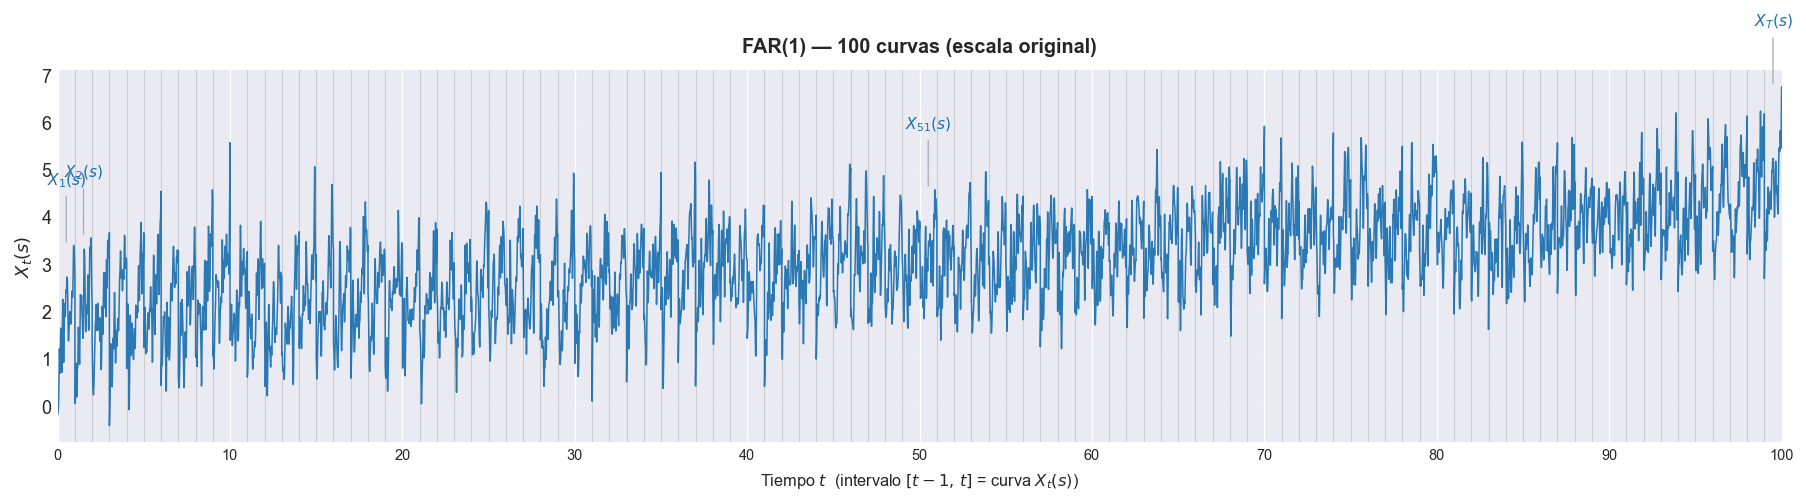

In [9]:
# ── 2.1 Dominio y operador Ψ ──────────────────────────────────────────────────
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])
Psi    = build_integral_matrix(
    domain, gaussian_integral_kernel,
    bandwidth = FAR_PARAMS["bandwidth"],
    decay     = FAR_PARAMS["decay"],
)

# ── 2.2 Simulación FAR(1) ─────────────────────────────────────────────────────
sim = FARSimulator(
    domain       = domain,
    n_curves     = FAR_PARAMS["n_curves"],
    Psi          = Psi,
    trend        = "linear",
    trend_params = {
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std    = FAR_PARAMS["noise_std"],
    noise_type   = FAR_PARAMS["noise_type"],
    burn_in      = FAR_PARAMS["burn_in"],
    random_state = SEED,
)
X_raw = sim.simulate()   # (T, G)
T, G  = X_raw.shape
print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")

fig = plot_functional_time_series(
    X_raw, domain.grid,
    highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1],
    title         = f"FAR(1) — {sim.n_curves} curvas (escala original)",
)
plt.show()


# 3. Estandarización por columna

Aplicamos z-score columna a columna. Guardamos $(\bar{X}_{\cdot,g}, \sigma_{X_{\cdot,g}})$
por si se necesita invertir la transformación posteriormente.

X estandarizada : shape=(100, 100)
  media por columna (debe ≈ 0): max|·| = 3.45e-15
  std   por columna (debe ≈ 1): max|·-1| = 5.55e-16


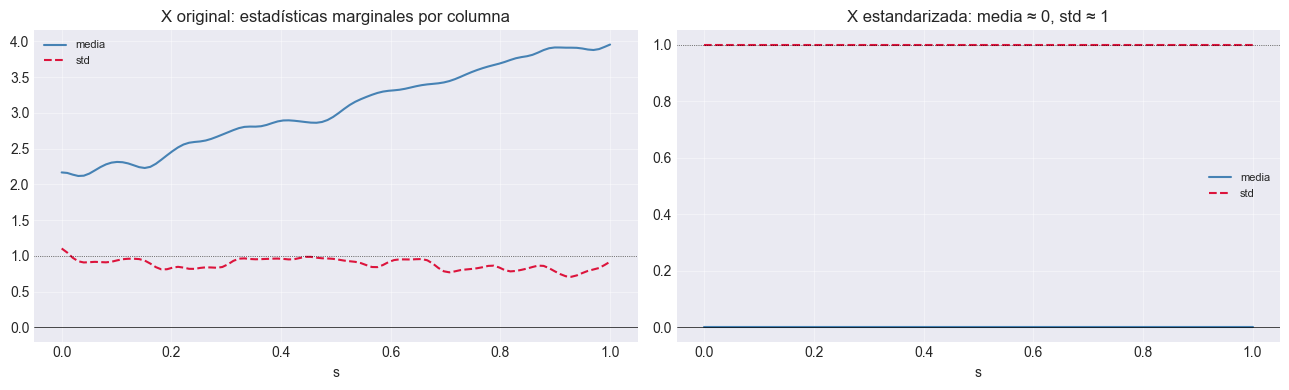

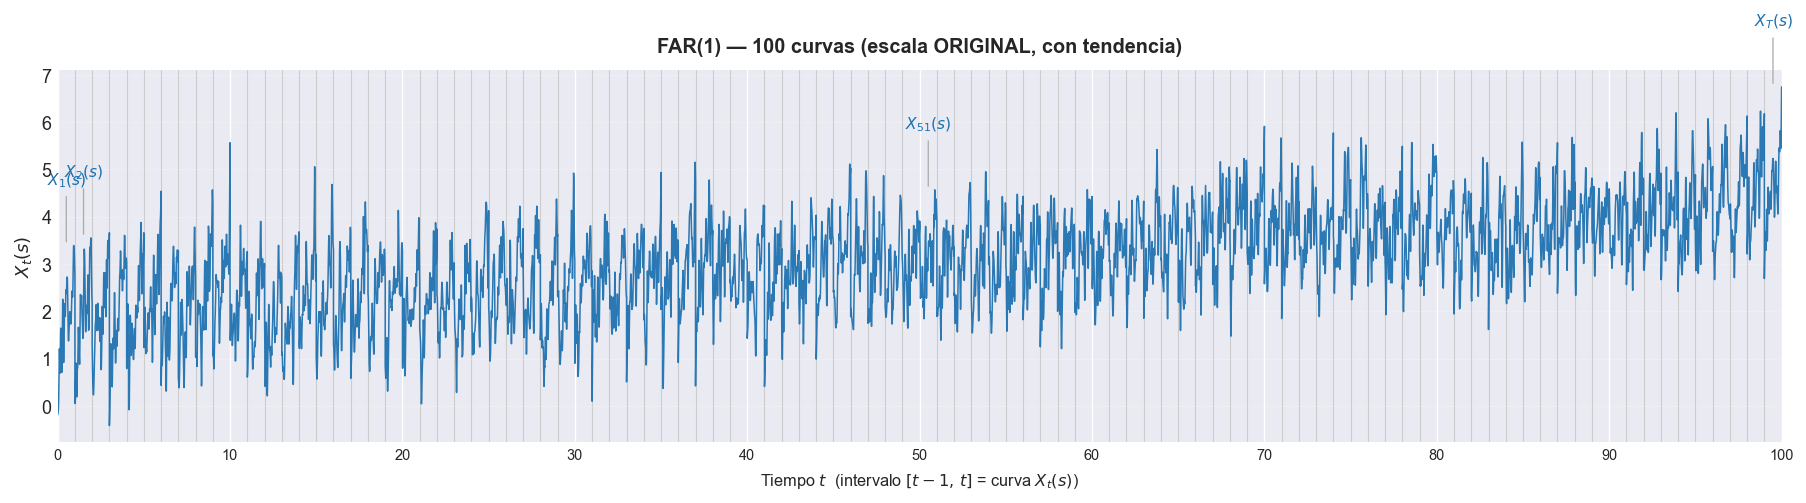

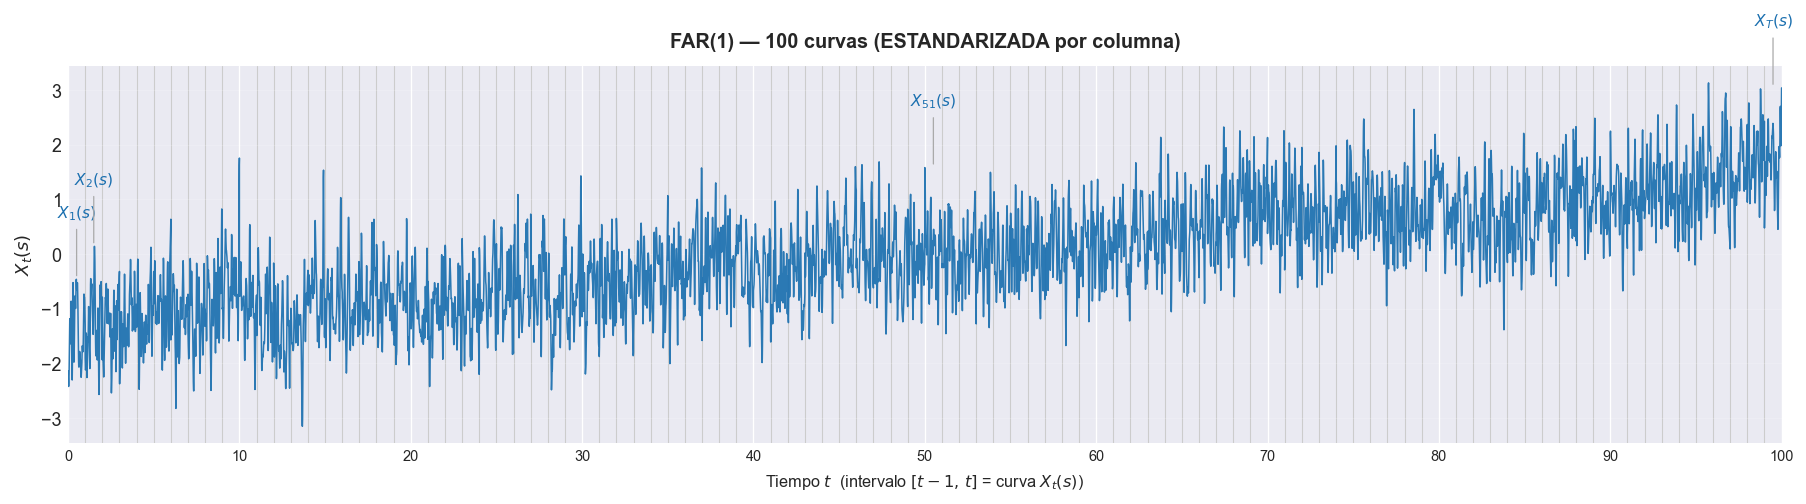

In [10]:
# ── 3.1 z-score por columna ──────────────────────────────────────────────────
X_mean = X_raw.mean(axis=0)                              # (G,)
X_std  = X_raw.std(axis=0, ddof=STANDARIZE_CONFIG["ddof"])  # (G,)

# Salvaguarda: columnas con varianza nula no pueden estandarizarse
if np.any(X_std == 0):
    zero_cols = np.where(X_std == 0)[0]
    raise ValueError(f"Columnas con varianza nula: {zero_cols.tolist()}")

X = (X_raw - X_mean) / X_std        # (T, G) — escala estandarizada
print(f"X estandarizada : shape={X.shape}")
print(f"  media por columna (debe ≈ 0): max|·| = {np.abs(X.mean(axis=0)).max():.2e}")
print(f"  std   por columna (debe ≈ 1): max|·-1| = {np.abs(X.std(axis=0)-1).max():.2e}")

# ── 3.2 Diagnóstico de la estandarización por columna ────────────────────────
# Verifica visualmente que las estadísticas marginales por punto de grilla s
# fueron correctamente neutralizadas (media → 0, std → 1).
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(domain.grid, X_raw.mean(axis=0), color="steelblue", lw=1.5, label="media")
axes[0].plot(domain.grid, X_raw.std(axis=0),  color="crimson",   lw=1.5, ls="--", label="std")
axes[0].axhline(0, color="k", lw=0.5)
axes[0].axhline(1, color="k", lw=0.5, ls=":")
axes[0].set_title("X original: estadísticas marginales por columna")
axes[0].set_xlabel("s")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.4)

axes[1].plot(domain.grid, X.mean(axis=0), color="steelblue", lw=1.5, label="media")
axes[1].plot(domain.grid, X.std(axis=0),  color="crimson",   lw=1.5, ls="--", label="std")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axhline(1, color="k", lw=0.5, ls=":")
axes[1].set_title("X estandarizada: media ≈ 0, std ≈ 1")
axes[1].set_xlabel("s")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── 3.3 Series funcionales completas: original vs estandarizada ──────────────
# Mismo formato que la sección 2 (curvas concatenadas en el eje temporal),
# para apreciar la remoción de la tendencia temporal.
highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1]

fig_raw = plot_functional_time_series(
    X_raw, domain.grid,
    highlight_idx = highlight_idx,
    title         = f"FAR(1) — {sim.n_curves} curvas (escala ORIGINAL, con tendencia)",
)
plt.show()

fig_std = plot_functional_time_series(
    X, domain.grid,
    highlight_idx = highlight_idx,
    title         = f"FAR(1) — {sim.n_curves} curvas (ESTANDARIZADA por columna)",
)
plt.show()

# 4. Representación funcional: B-spline

Scores THETA : (100, 5)
  Basis 1: mean=  0.0000  std= 1.0329  range=[ -2.137,   2.665]
  Basis 2: mean= -0.0000  std= 1.8515  range=[ -4.764,   3.909]
  Basis 3: mean=  0.0000  std= 2.6521  range=[ -5.175,   6.353]
  Basis 4: mean= -0.0000  std= 2.1303  range=[ -5.605,   4.852]
  Basis 5: mean= -0.0000  std= 1.0637  range=[ -2.271,   3.062]

Varianza retenida por la base B-spline (5 funciones):
  74.7645%
  RMSE medio por curva  : 0.498245
  RMSE máx              : 0.626994
  RMSE mín              : 0.330273
  Varianza retenida     : 74.76%


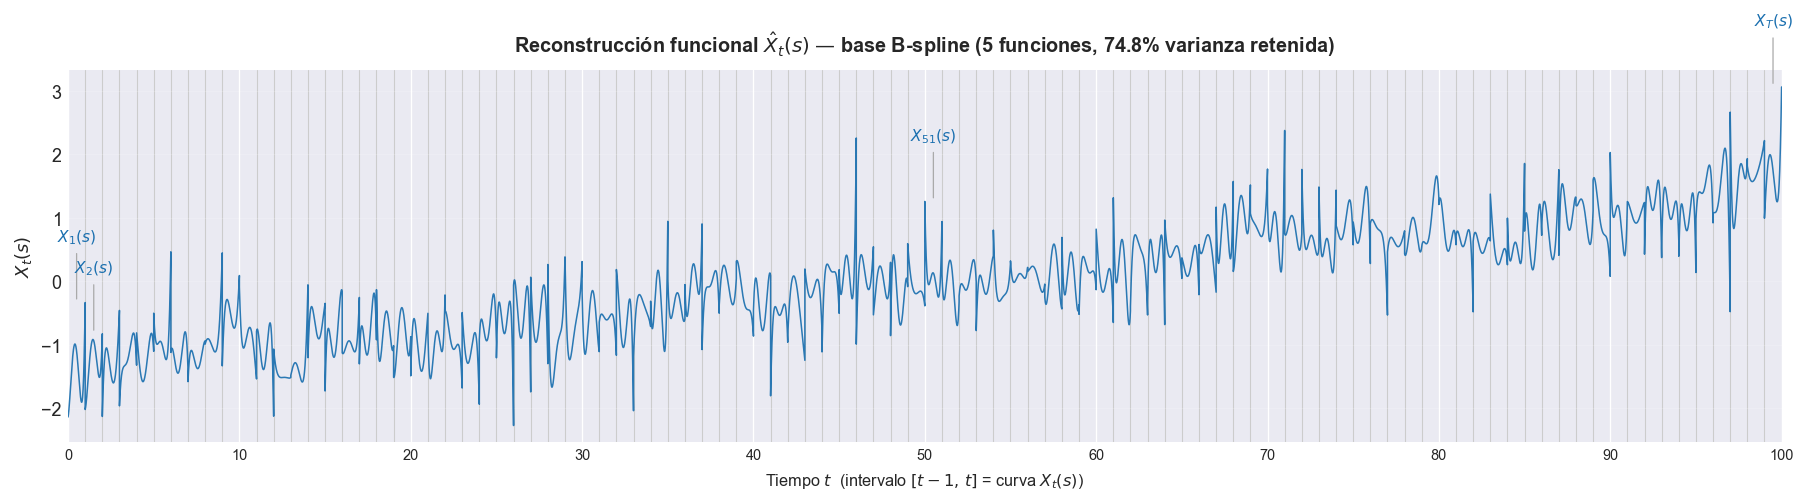

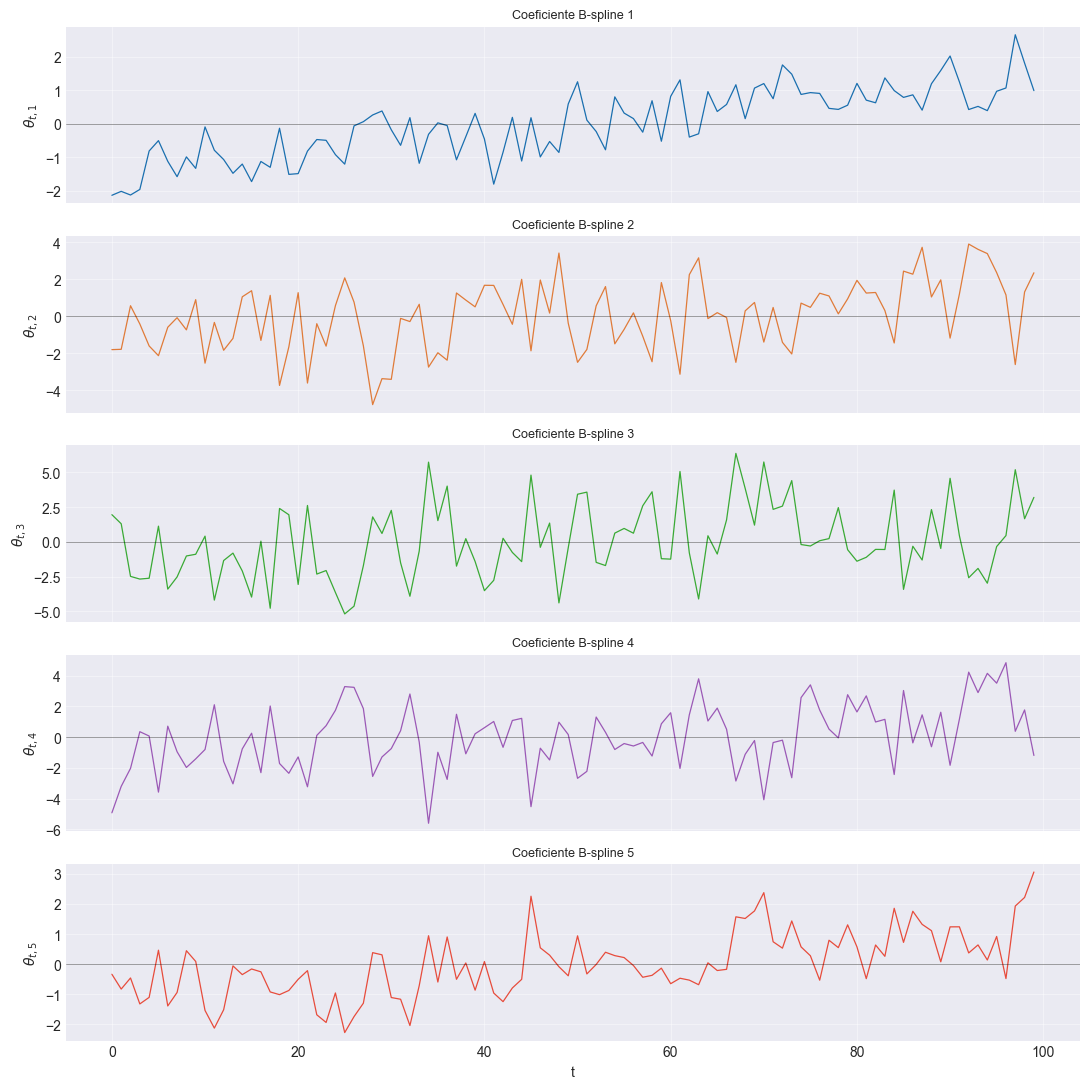

In [17]:
# ── 4.1 Fit + transform ─────────────────────────────────────────────────────
fr    = FunctionalRepresentation(
    method       = "bspline",
    n_basis      = REPRE_PARAMS["n_basis"],
    order        = REPRE_PARAMS["order"],
)
THETA = fr.fit_transform(X, domain.grid)   # (T, n_basis)
n_components = THETA.shape[1]

print(f"Scores THETA : {THETA.shape}")
for k in range(n_components):
    print(f"  Basis {k+1}: mean={THETA[:,k].mean():>8.4f}  std={THETA[:,k].std():>7.4f}  "
          f"range=[{THETA[:,k].min():>7.3f}, {THETA[:,k].max():>7.3f}]")

# ── 4.2 Varianza retenida (bspline: via reconstrucción) ─────────────────────
# Con bspline no hay ranking de componentes por varianza explicada;
# se reporta la varianza global retenida por la base completa.
X_repr     = fr.reconstruct(THETA)                          # (T, G)
ss_res     = np.sum((X - X_repr) ** 2)
ss_tot     = np.sum((X - X.mean(axis=0, keepdims=True)) ** 2)
var_retained = 1.0 - ss_res / ss_tot

print(f"\nVarianza retenida por la base B-spline ({n_components} funciones):")
print(f"  {var_retained * 100:.4f}%")

# ── 4.3 Reconstrucción funcional ─────────────────────────────────────────────
rmse_repr = np.sqrt(np.mean((X - X_repr) ** 2, axis=1))

print(f"  RMSE medio por curva  : {rmse_repr.mean():.6f}")
print(f"  RMSE máx              : {rmse_repr.max():.6f}")
print(f"  RMSE mín              : {rmse_repr.min():.6f}")
print(f"  Varianza retenida     : {var_retained * 100:.2f}%")

highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1]

fig_repr = plot_functional_time_series(
    X_repr, domain.grid,
    highlight_idx = highlight_idx,
    title         = (
        f"Reconstrucción funcional $\\hat{{X}}_t(s)$ "
        f"— base B-spline ({n_components} funciones, "
        f"{var_retained * 100:.1f}% varianza retenida)"
    ),
)
plt.show()

# ── 4.4 Coeficientes B-spline como series de tiempo ──────────────────────────
colors = ["#1a6faf", "#e07b39", "#3aaa35", "#9b59b6", "#e74c3c"]
fig, axes = plt.subplots(n_components, 1, figsize=(11, 2.2 * n_components), sharex=True)
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), THETA[:, k], lw=0.9, color=colors[k % len(colors)])
    ax.axhline(0, color="k", lw=0.5, alpha=0.5)
    ax.set_ylabel(rf"$\theta_{{t,{k+1}}}$")
    ax.set_title(f"Coeficiente B-spline {k+1}", fontsize=9)
    ax.grid(True, alpha=0.4)
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

# 5. Construcción de DataFrames AR(1)

Para cada componente $k$:
- columna 0 → respuesta: $\theta_{t,k}$ (filas $t = 2, \dots, T$)
- columna 1 → covariable: $\theta_{t-1,k}$ (rezago)

Se pierde una observación por el lag → $T-1$ filas.

FPC 1: shape=(99, 6)  n_covariables=5
FPC 2: shape=(99, 6)  n_covariables=5
FPC 3: shape=(99, 6)  n_covariables=5
FPC 4: shape=(99, 6)  n_covariables=5
FPC 5: shape=(99, 6)  n_covariables=5

Columnas del DataFrame para FPC 1:
  ['theta_1', 'theta_1_lag1', 'theta_2_lag1', 'theta_3_lag1', 'theta_4_lag1', 'theta_5_lag1']


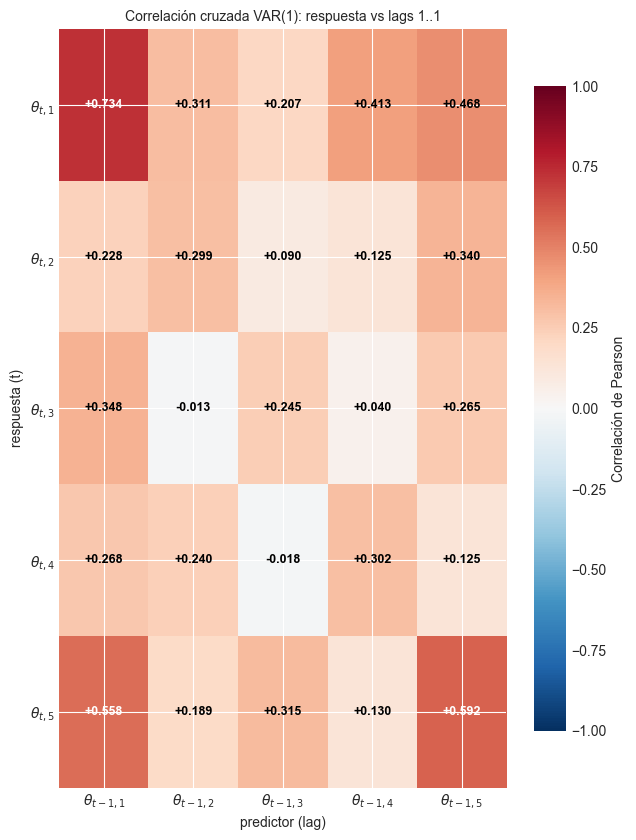


DataFrame del modelo para FPC 1  (shape=(99, 6)):


,theta_1,theta_1_lag1,theta_2_lag1,theta_3_lag1,theta_4_lag1,theta_5_lag1
0,-2.018881,-2.136863,-1.793730,1.952134,-4.924961,-0.334742
1,-2.128535,-2.018881,-1.776927,1.299400,-3.203618,-0.826388
2,-1.961436,-2.128535,0.577797,-2.479412,-2.030965,-0.458024
3,-0.811677,-1.961436,-0.407796,-2.672316,0.358010,-1.320343
4,-0.501944,-0.811677,-1.595934,-2.612017,0.075288,-1.102385


In [20]:
# ── 5. Construcción de DataFrames VAR(p) ecuación por ecuación ───────────────
N_LAGS = 1

dfs = {}
for k in range(n_components):
    cols = {f"theta_{k+1}": THETA[N_LAGS:, k]}

    for lag in range(1, N_LAGS + 1):
        for j in range(n_components):
            cols[f"theta_{j+1}_lag{lag}"] = THETA[N_LAGS - lag : THETA.shape[0] - lag, j]

    dfs[k] = pd.DataFrame(cols)
    print(f"FPC {k+1}: shape={dfs[k].shape}  "
          f"n_covariables={dfs[k].shape[1] - 1}")

print(f"\nColumnas del DataFrame para FPC 1:")
print(f"  {list(dfs[0].columns)}")

# ── Diagnóstico: matriz de correlaciones cruzadas ────────────────────────────
n_cov      = n_components * N_LAGS
corr_cross = np.zeros((n_components, n_cov))

y_block    = THETA[N_LAGS:, :]                                 # (T - N_LAGS, n_components)
col_labels = []
for lag in range(1, N_LAGS + 1):
    x_block = THETA[N_LAGS - lag : THETA.shape[0] - lag, :]
    for j in range(n_components):
        col_idx = (lag - 1) * n_components + j
        for k in range(n_components):
            corr_cross[k, col_idx] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        col_labels.append(rf"$\theta_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\theta_{{t,{k+1}}}$" for k in range(n_components)]

# ── Visualización: heatmap matplotlib ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(0.9 * n_cov + 2, 1.6 * n_components + 0.5))
im = ax.imshow(corr_cross, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(n_cov))
ax.set_xticklabels(col_labels, fontsize=10, rotation=0)
ax.set_yticks(range(n_components))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xlabel("predictor (lag)")
ax.set_ylabel("respuesta (t)")
ax.set_title(
    f"Correlación cruzada VAR({N_LAGS}): respuesta vs lags 1..{N_LAGS}",
    fontsize=10,
)

for lag in range(1, N_LAGS):
    ax.axvline(lag * n_components - 0.5, color="black", lw=1.2)

for i in range(n_components):
    for j in range(n_cov):
        val = corr_cross[i, j]
        ax.text(j, i, f"{val:+.3f}",
                ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black",
                fontsize=9, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.85, label="Correlación de Pearson")
plt.tight_layout()
plt.show()

print(f"\nDataFrame del modelo para FPC 1  (shape={dfs[0].shape}):")
display(dfs[0].head())

# 6. Ajuste PSBP-FD: C cadenas × K componentes

Ajustamos `N_CHAINS` cadenas independientes (semillas distintas) por cada uno de los
`componentes` componentes. Estructura final:

```
models_chains[k][c] = PSBP_FD_v1 entrenado (componente k, cadena c)
```

In [21]:
import time

models_chains = {k: {} for k in range(n_components)}
fit_times     = {k: {} for k in range(n_components)}

t_global = time.perf_counter()
for k in range(n_components):
    print(f"\n{'='*60}")
    print(f"  FPC {k+1}  —  ajustando {N_CHAINS} cadenas")
    print(f"  DataFrame: shape={dfs[k].shape}, p={dfs[k].shape[1] - 1} covariables")
    print(f"{'='*60}")
    for c, seed_c in enumerate(CHAIN_SEEDS):
        print(f"\n  ── cadena {c+1}/{N_CHAINS}  (seed={seed_c}) ──")
        t0 = time.perf_counter()
        m = PSBP_FD_v1(
            mcmc_cfg      = MCMC_CONFIG,
            hp            = HYPERPARAMS,
            seed          = seed_c,
            verbose_every = 100,
        )
        m.fit(dfs[k])
        elapsed = time.perf_counter() - t0
        models_chains[k][c] = m
        fit_times[k][c]     = elapsed
        print(f"  [OK] FPC {k+1} | cadena {c+1}  "
              f"({elapsed:.1f}s, n_features={m.n_features_})")

t_total = time.perf_counter() - t_global
print(f"\n{'='*60}")
print(f"Todos los modelos ajustados — tiempo total: {t_total:.1f}s "
      f"({t_total/60:.1f} min)")
print(f"Tiempo medio por cadena: {t_total / (n_components * N_CHAINS):.1f}s")
print(f"{'='*60}")


  FPC 1  —  ajustando 3 cadenas
  DataFrame: shape=(99, 6), p=5 covariables

  ── cadena 1/3  (seed=42) ──
  iter 100/1000
  iter 200/1000
  iter 300/1000
  iter 400/1000
  iter 500/1000
  iter 600/1000
  iter 700/1000
  iter 800/1000
  iter 900/1000
  iter 1000/1000
  [OK] FPC 1 | cadena 1  (1498.5s, n_features=5)

  ── cadena 2/3  (seed=142) ──
  iter 100/1000
  iter 200/1000
  iter 300/1000
  iter 400/1000
  iter 500/1000
  iter 600/1000
  iter 700/1000
  iter 800/1000
  iter 900/1000
  iter 1000/1000
  [OK] FPC 1 | cadena 2  (1435.0s, n_features=5)

  ── cadena 3/3  (seed=242) ──
  iter 100/1000
  iter 200/1000
  iter 300/1000
  iter 400/1000
  iter 500/1000
  iter 600/1000
  iter 700/1000
  iter 800/1000
  iter 900/1000
  iter 1000/1000
  [OK] FPC 1 | cadena 3  (1470.9s, n_features=5)

  FPC 2  —  ajustando 3 cadenas
  DataFrame: shape=(99, 6), p=5 covariables

  ── cadena 1/3  (seed=42) ──
  iter 100/1000
  iter 200/1000
  iter 300/1000
  iter 400/1000
  iter 500/1000
  iter 600

C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\model_psbp_fd\models\psbp_fd_v1\functions\sampler.py:73: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return rng.multivariate_normal(mu.ravel(), cov)


  iter 500/1000
  iter 600/1000
  iter 700/1000
  iter 800/1000
  iter 900/1000
  iter 1000/1000
  [OK] FPC 5 | cadena 3  (1438.9s, n_features=5)

Todos los modelos ajustados — tiempo total: 21576.3s (359.6 min)
Tiempo medio por cadena: 1438.4s


# 7. Diagnósticos de convergencia

Trabajamos sobre las trazas post burn-in. Para parámetros multidimensionales (átomos,
variables) tomamos la **media sobre la dimensión de átomos** para obtener un escalar por
iteración. Esto reduce dimensión y captura el comportamiento agregado del componente.

## Estadísticos implementados

| Estadístico | Fórmula / referencia | Lectura |
|---|---|---|
| ACF(lag) | $\hat{\rho}_h = \widehat{\text{Cov}}(x_t, x_{t+h}) / \widehat{\text{Var}}(x_t)$ | autocorrelación residual: cerca de 0 ⇒ buen mezcla |
| ESS | $\text{ESS} = N / (1 + 2 \sum_{h=1}^{H} \hat{\rho}_h)$ (Geyer, 1992) | tamaño efectivo: ESS ≳ 400 ideal |
| Geweke z | $z = (\bar{x}_A - \bar{x}_B) / \sqrt{\hat{\sigma}^2_A/n_A + \hat{\sigma}^2_B/n_B}$ | $\|z\| < 2$ ⇒ no rechazo igualdad de medias entre dos sub-cadenas |
| Gelman-Rubin R̂ | $\hat{R} = \sqrt{((n-1)/n + (m+1)/(mn) \cdot B/W)}$ | R̂ < 1.1 ⇒ convergencia entre cadenas (Brooks-Gelman 1998) |

Implementamos cada uno *desde cero* sin dependencias externas (`arviz`) para mantener
auditabilidad del cálculo.

## 7.1 Funciones auxiliares de diagnóstico

In [23]:
def autocorr(x: np.ndarray, max_lag: int = 100) -> np.ndarray:
    """
    Autocorrelación muestral hasta `max_lag` (incluye lag 0 = 1.0).
    Implementación vía FFT (eficiente para cadenas largas).
    """
    x = np.asarray(x, dtype=np.float64).ravel()
    n = len(x)
    x_c = x - x.mean()
    # padding para FFT lineal (evita correlación circular)
    nfft = 1 << (2 * n - 1).bit_length()
    f = np.fft.rfft(x_c, n=nfft)
    acf_full = np.fft.irfft(f * np.conj(f), n=nfft)[:n]
    acf_full /= acf_full[0]
    return acf_full[: max_lag + 1]


def ess_geyer(x: np.ndarray) -> float:
    """
    Effective Sample Size con regla de truncamiento de Geyer:
    suma autocorrelaciones por pares (lag impar+par) mientras la suma sea positiva.
    Referencia: Geyer (1992) "Practical Markov Chain Monte Carlo", Statistical Science.
    """
    x = np.asarray(x, dtype=np.float64).ravel()
    n = len(x)
    rho = autocorr(x, max_lag=min(n - 1, 1000))
    # Truncamiento de Geyer (initial positive sequence)
    s = 0.0
    for k in range(1, len(rho) - 1, 2):
        pair = rho[k] + rho[k + 1]
        if pair < 0:
            break
        s += pair
    tau_int = 1.0 + 2.0 * s
    return float(n / tau_int) if tau_int > 0 else float(n)


def geweke_z(x: np.ndarray, first: float = 0.1, last: float = 0.5) -> float:
    """
    Diagnóstico de Geweke: test z de igualdad de medias entre la primera
    fracción `first` y la última fracción `last` de la cadena.
    Varianzas estimadas con corrección por autocorrelación (vía ESS).
    """
    x = np.asarray(x, dtype=np.float64).ravel()
    n = len(x)
    n_a = int(first * n)
    n_b = int(last  * n)
    if n_a < 2 or n_b < 2:
        return np.nan
    x_a = x[:n_a]
    x_b = x[-n_b:]
    mean_a, mean_b = x_a.mean(), x_b.mean()
    var_a = x_a.var(ddof=1) / max(ess_geyer(x_a), 1.0)
    var_b = x_b.var(ddof=1) / max(ess_geyer(x_b), 1.0)
    denom = np.sqrt(var_a + var_b)
    if denom == 0 or not np.isfinite(denom):
        return np.nan
    return float((mean_a - mean_b) / denom)


def gelman_rubin(chains: np.ndarray) -> float:
    """
    Estadístico R̂ de Gelman-Rubin (Brooks-Gelman 1998).
    `chains` shape: (m, n) con m cadenas de longitud n (ya descontado burn-in).
    """
    chains = np.asarray(chains, dtype=np.float64)
    if chains.ndim != 2:
        raise ValueError("chains debe ser 2D (m_chains, n_iter)")
    m, n = chains.shape
    if m < 2 or n < 2:
        return np.nan
    chain_means = chains.mean(axis=1)                       # (m,)
    chain_vars  = chains.var(axis=1, ddof=1)                # (m,)
    grand_mean  = chain_means.mean()
    B = n * chain_means.var(ddof=1)                         # between
    W = chain_vars.mean()                                   # within
    if W == 0:
        return np.nan
    var_hat = (n - 1) / n * W + (1.0 / n) * B               # estimador combinado
    return float(np.sqrt(var_hat / W))


def aggregate_trace(trace: np.ndarray, burn: int) -> np.ndarray:
    """
    Convierte una traza de shape (nsim,), (nsim, K) o (nsim, K1, K2) en
    un vector 1D de longitud (nsim - burn), promediando sobre las dimensiones
    de átomos/variables.
    """
    trace = np.asarray(trace)
    if trace.ndim == 1:
        agg = trace
    elif trace.ndim == 2:
        agg = trace.mean(axis=1)
    elif trace.ndim == 3:
        agg = trace.mean(axis=(1, 2))
    else:
        raise ValueError(f"ndim no soportado: {trace.ndim}")
    return agg[burn:].astype(np.float64)


print("Funciones de diagnóstico listas: autocorr, ess_geyer, geweke_z, gelman_rubin, aggregate_trace.")


Funciones de diagnóstico listas: autocorr, ess_geyer, geweke_z, gelman_rubin, aggregate_trace.


## 7.2 Selección de parámetros a diagnosticar

Tomamos un conjunto representativo: **escalares globales** + **agregados de parámetros
principales**. Sobre cada uno se calculan los cuatro estadísticos.

In [24]:
# Trazas seleccionadas (clave en sampler.traces → etiqueta legible)
PARAMS_TO_DIAGNOSE = {
    "muout":      r"$\mu$ (media global)",
    "N1out":      r"$N^{(1)}$ (átomos activos máx)",
    "Nout":       r"$N$ (truncamiento efectivo)",
    "beta0hout":  r"$\bar{\beta}_{0,h}$ (intercepto agregado)",
    "tauhout":    r"$\bar{\tau}_h$ (precisión agregada)",
    "alphahout":  r"$\bar{\alpha}_h$ (umbral PSBP agregado)",
    "pijout":     r"$\bar{p}_{ij}$ (prob. inclusión agregada)",
}
print(f"Parámetros a diagnosticar ({len(PARAMS_TO_DIAGNOSE)}):")
for key, lbl in PARAMS_TO_DIAGNOSE.items():
    print(f"  {key:<12} → {lbl}")


Parámetros a diagnosticar (7):
  muout        → $\mu$ (media global)
  N1out        → $N^{(1)}$ (átomos activos máx)
  Nout         → $N$ (truncamiento efectivo)
  beta0hout    → $\bar{\beta}_{0,h}$ (intercepto agregado)
  tauhout      → $\bar{\tau}_h$ (precisión agregada)
  alphahout    → $\bar{\alpha}_h$ (umbral PSBP agregado)
  pijout       → $\bar{p}_{ij}$ (prob. inclusión agregada)


## 7.3 Cálculo masivo de diagnósticos

In [26]:
burn = MCMC_CONFIG["burn"]

diag_records = []

for k in range(n_components):
    for param in PARAMS_TO_DIAGNOSE.keys():
        per_chain = []
        for c in range(N_CHAINS):
            trace_c = models_chains[k][c].traces[param]
            per_chain.append(aggregate_trace(trace_c, burn))
        chains_mat = np.vstack(per_chain)   # (N_CHAINS, n_post)

        ess_c    = [ess_geyer(chains_mat[c]) for c in range(N_CHAINS)]
        geweke_c = [geweke_z(chains_mat[c])  for c in range(N_CHAINS)]
        rhat     = gelman_rubin(chains_mat)

        diag_records.append({
            "component":     k + 1,          # renombrado de "FPC"
            "param":         param,
            "ESS_min":       float(np.min(ess_c)),
            "ESS_mean":      float(np.mean(ess_c)),
            "ESS_max":       float(np.max(ess_c)),
            "|Geweke|_max":  float(np.max(np.abs(geweke_c))),
            "Rhat":          rhat,
            "converge":      (rhat < 1.1) and (np.min(ess_c) > 100) and (np.max(np.abs(geweke_c)) < 2.0),
        })

diag_df = pd.DataFrame(diag_records)
display(diag_df.style.format({
    "ESS_min":      "{:.1f}",
    "ESS_mean":     "{:.1f}",
    "ESS_max":      "{:.1f}",
    "|Geweke|_max": "{:+.2f}",
    "Rhat":         "{:.3f}",
}))

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


,component,param,ESS_min,ESS_mean,ESS_max,|Geweke|_max,Rhat,converge
0,1,muout,25.2,52.3,86.4,+0.65,1.307,False
1,1,N1out,48.9,57.4,68.3,+1.91,1.450,False
2,1,Nout,700.0,700.0,700.0,+nan,nan,False
3,1,beta0hout,347.4,414.8,451.6,+1.11,1.001,True
4,1,tauhout,163.9,224.1,256.9,+2.73,1.012,False
5,1,alphahout,24.3,50.1,81.2,+0.60,1.346,False
6,1,pijout,47.7,67.3,77.7,+1.63,1.018,False
7,2,muout,14.5,32.2,60.4,+2.40,1.067,False
8,2,N1out,7.7,28.4,67.5,+8.29,1.070,False
9,2,Nout,700.0,700.0,700.0,+nan,nan,False


## 7.4 Visualización de diagnósticos

Para cada componente y parámetro: **trazas superpuestas** (una por cadena) + **ACF
(0–80 lags)** + **histograma de la distribución posterior** combinada.

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


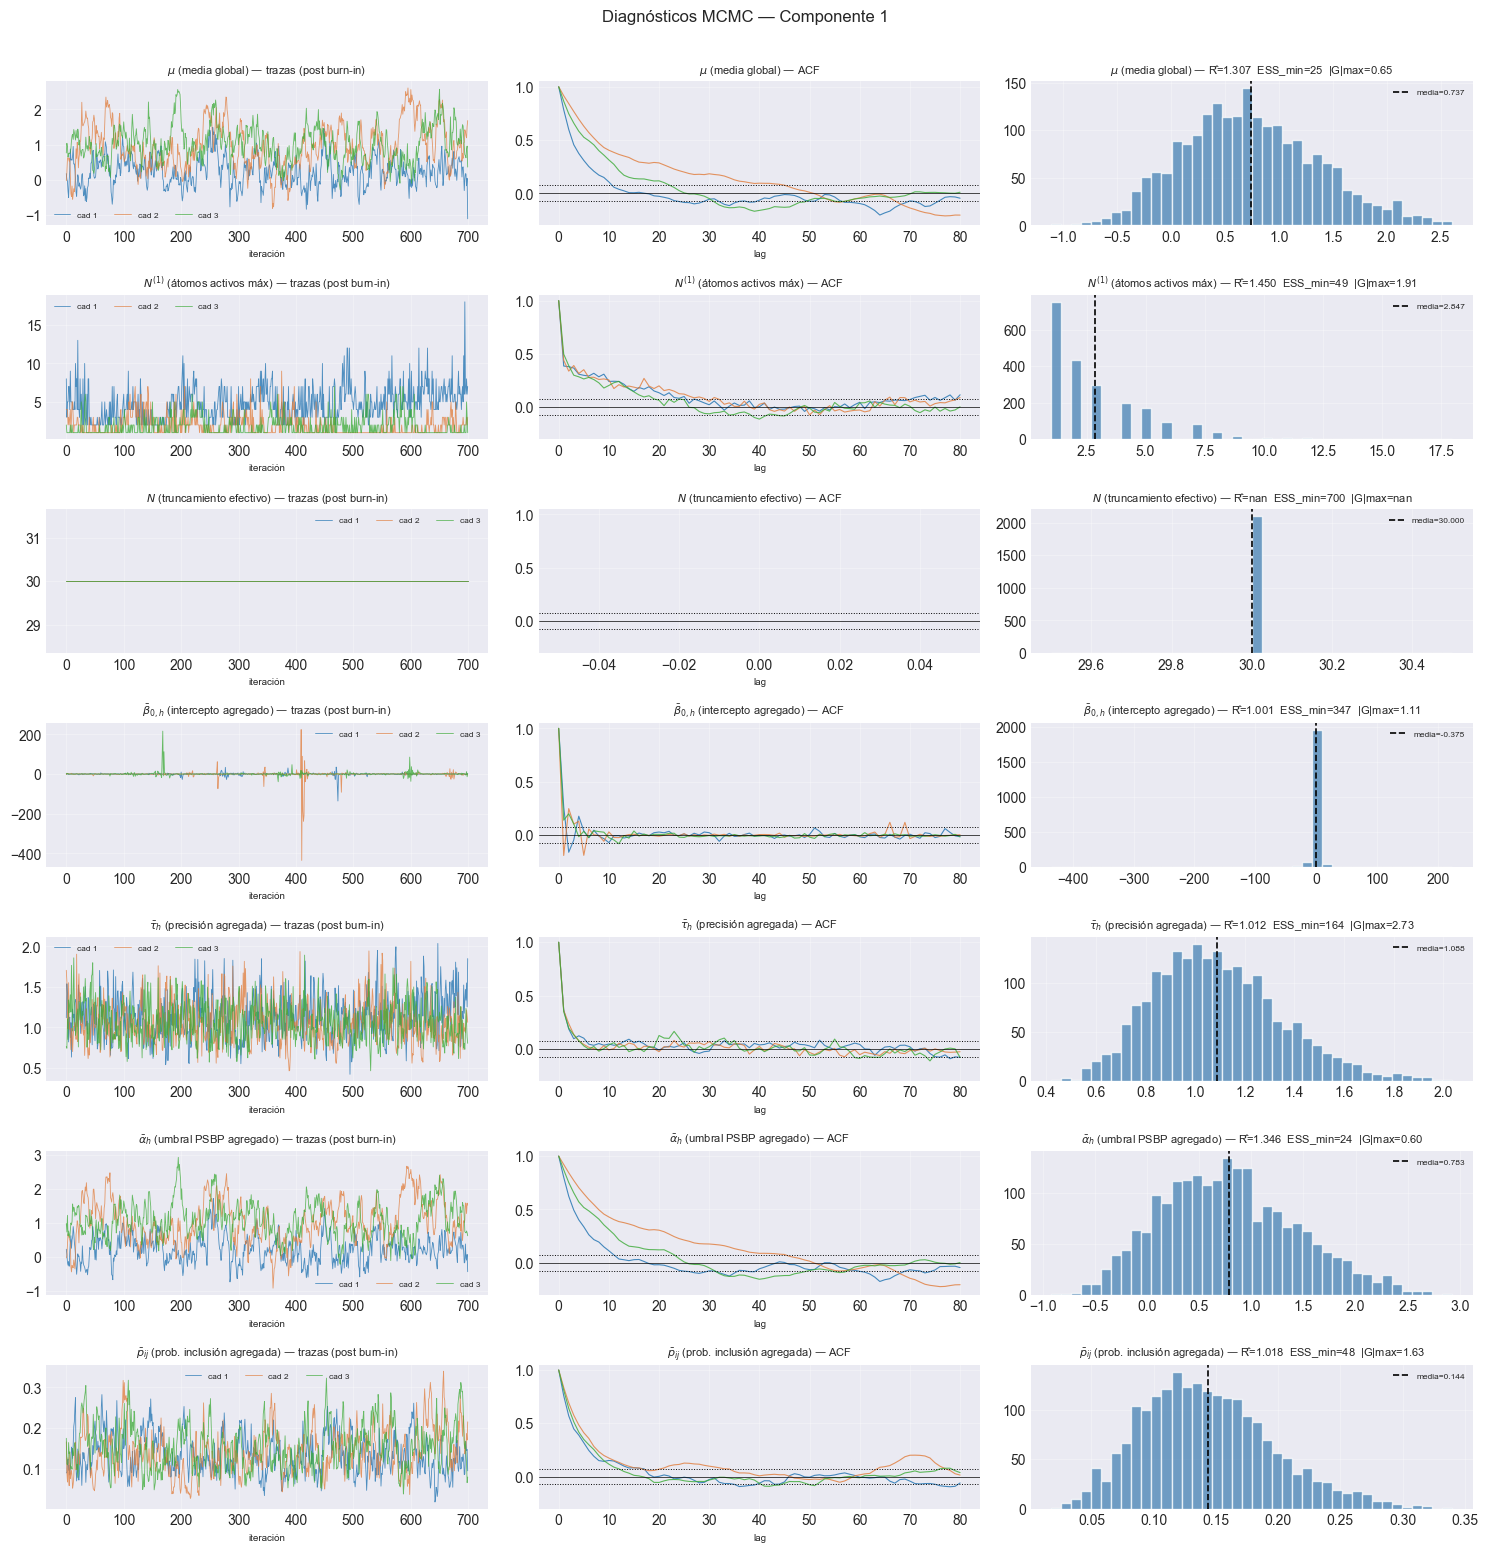

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


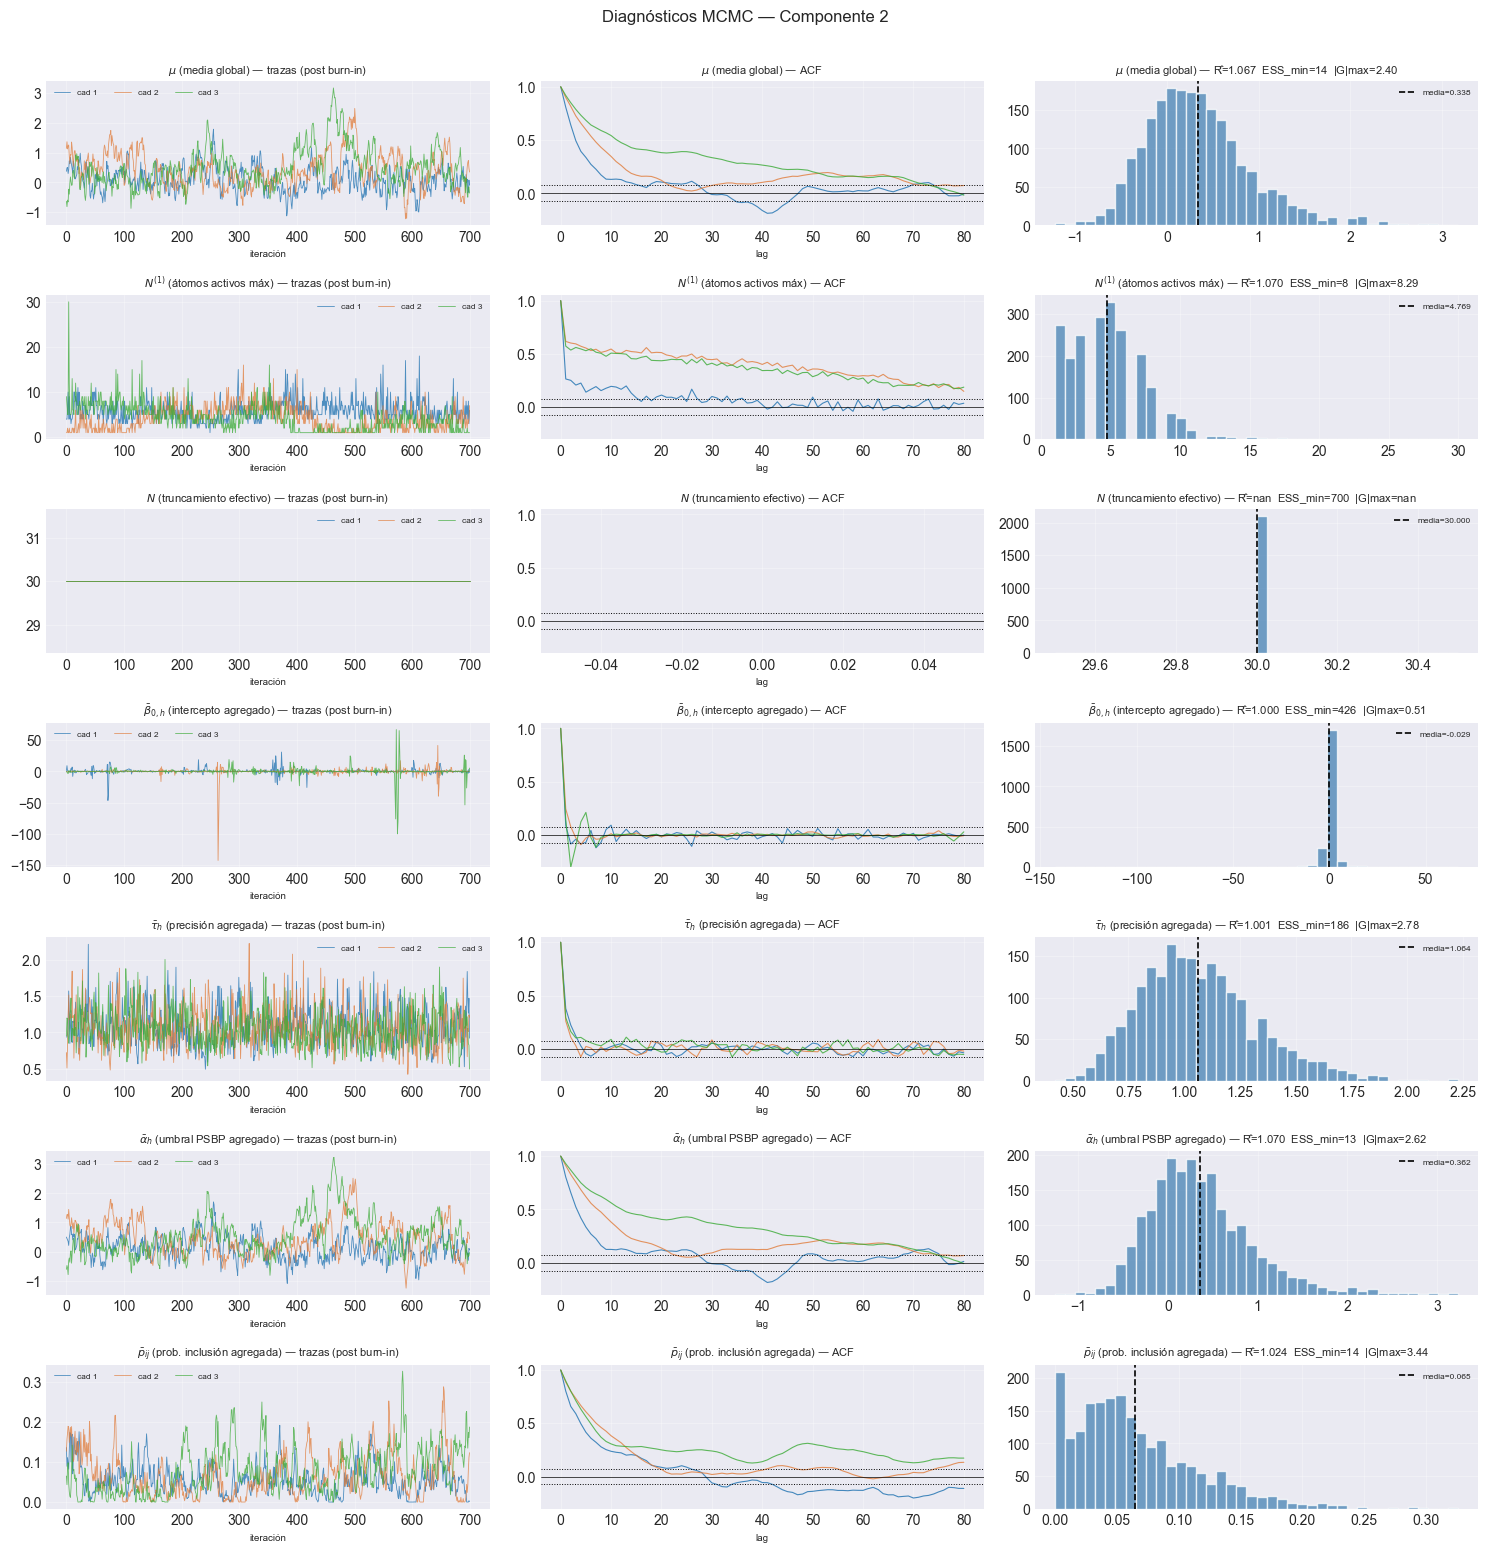

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


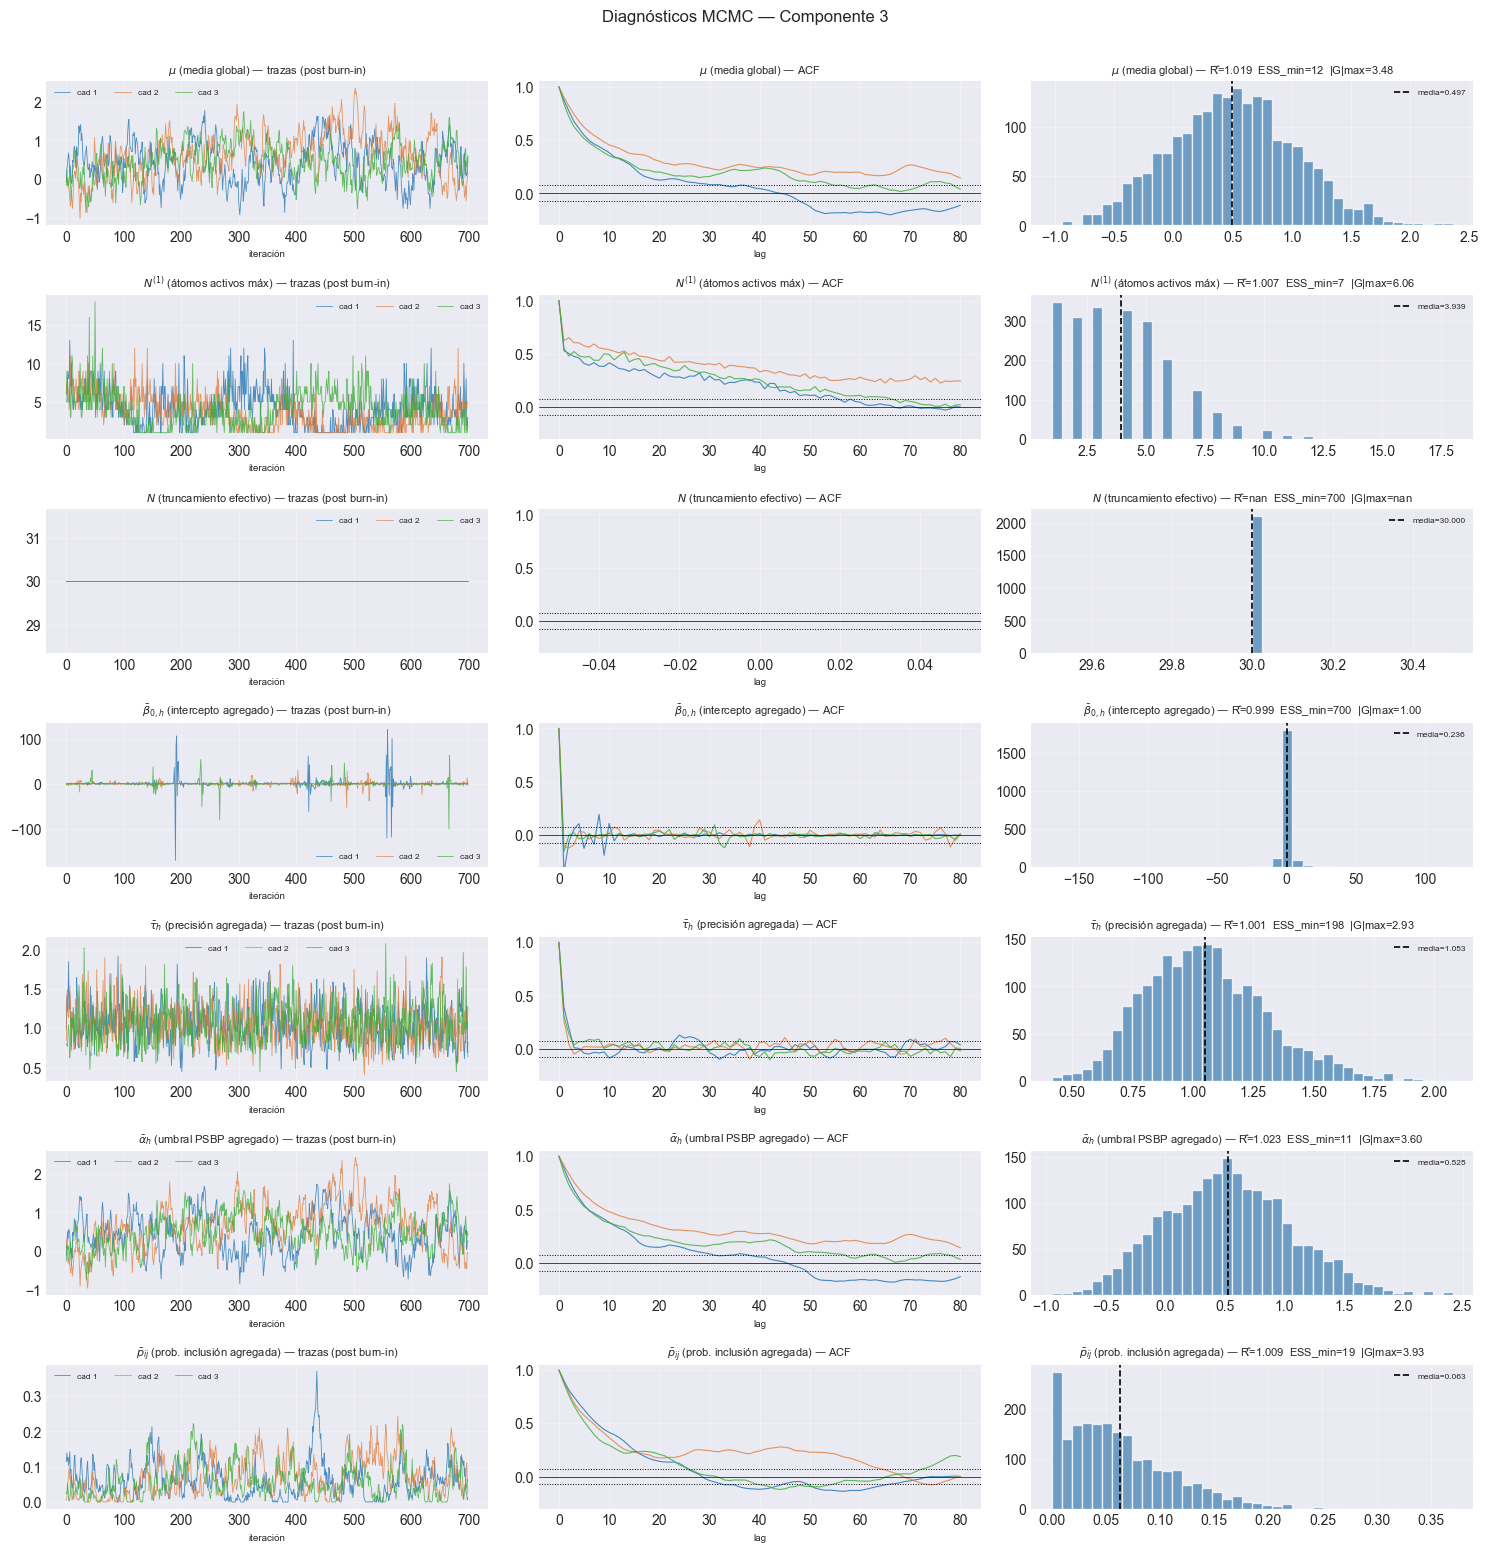

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


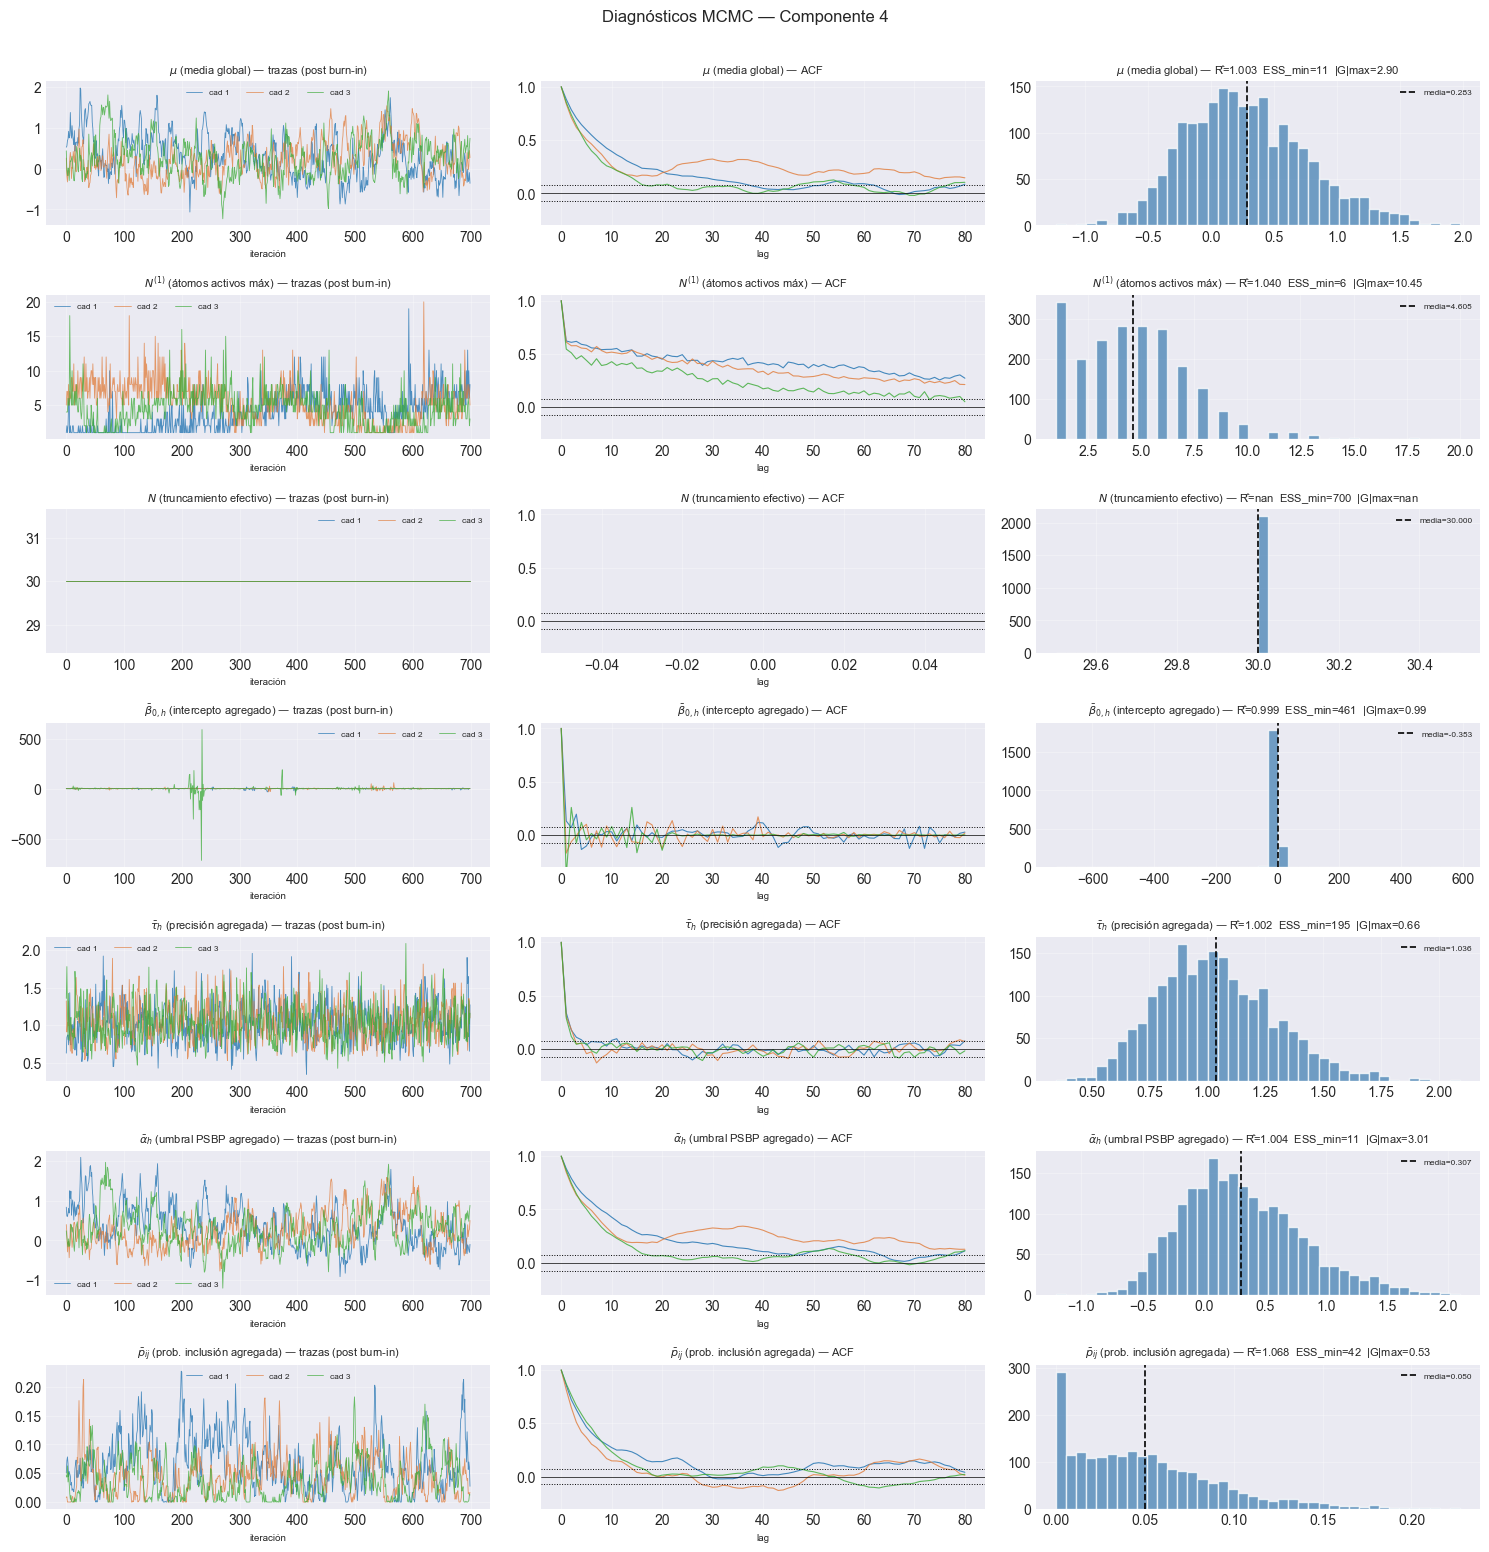

C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\3435549116.py:13: RuntimeWarning: invalid value encountered in divide
  acf_full /= acf_full[0]


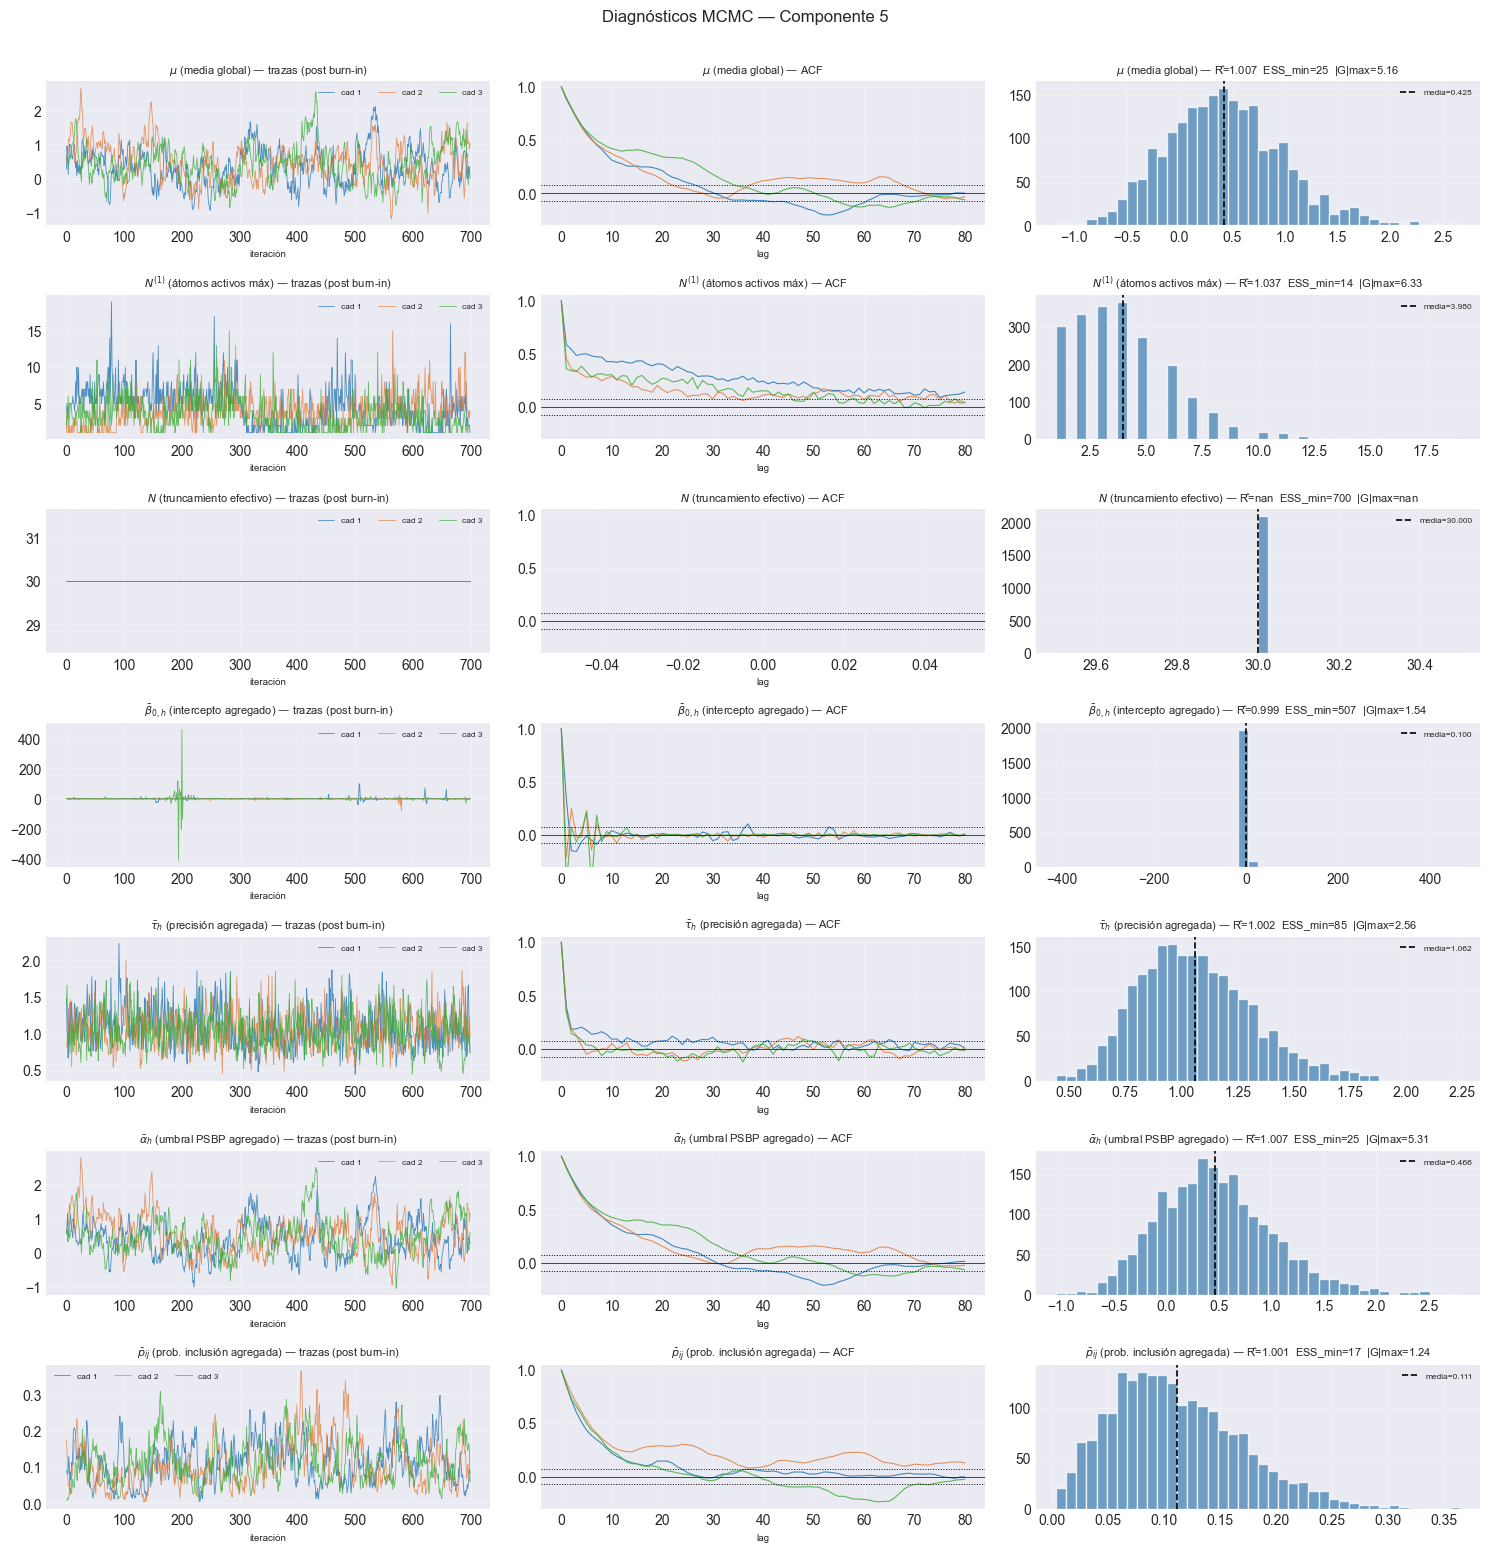

In [27]:
colors_chain = ["#1a6faf", "#e07b39", "#3aaa35", "#9b59b6", "#c0392b"]
n_params     = len(PARAMS_TO_DIAGNOSE)

for k in range(n_components):
    fig, axes = plt.subplots(n_params, 3, figsize=(15, 2.2 * n_params))
    fig.suptitle(f"Diagnósticos MCMC — Componente {k+1}", fontsize=12, y=1.005)

    for i, (param, lbl) in enumerate(PARAMS_TO_DIAGNOSE.items()):
        ax_trace, ax_acf, ax_post = axes[i]

        chains_post = [aggregate_trace(models_chains[k][c].traces[param], burn)
                       for c in range(N_CHAINS)]

        # ── (a) Trazas superpuestas ──
        for c, ch in enumerate(chains_post):
            ax_trace.plot(ch, lw=0.6, alpha=0.75, color=colors_chain[c],
                          label=f"cad {c+1}")
        ax_trace.set_title(f"{lbl} — trazas (post burn-in)", fontsize=8)
        ax_trace.set_xlabel("iteración", fontsize=7)
        ax_trace.legend(fontsize=6, ncol=N_CHAINS)
        ax_trace.grid(True, alpha=0.3)

        # ── (b) ACF por cadena ──
        max_lag = 80
        for c, ch in enumerate(chains_post):
            rho = autocorr(ch, max_lag=max_lag)
            ax_acf.plot(np.arange(max_lag + 1), rho, lw=0.8, alpha=0.8,
                        color=colors_chain[c])
        ax_acf.axhline(0, color="k", lw=0.5)
        n_post = len(chains_post[0])
        ax_acf.axhline( 1.96/np.sqrt(n_post), color="k", ls=":", lw=0.7)
        ax_acf.axhline(-1.96/np.sqrt(n_post), color="k", ls=":", lw=0.7)
        ax_acf.set_title(f"{lbl} — ACF", fontsize=8)
        ax_acf.set_xlabel("lag", fontsize=7)
        ax_acf.set_ylim(-0.3, 1.05)
        ax_acf.grid(True, alpha=0.3)

        # ── (c) Posterior combinada ──
        combined = np.concatenate(chains_post)
        ax_post.hist(combined, bins=40, color="steelblue", alpha=0.75,
                     edgecolor="white")
        ax_post.axvline(combined.mean(), color="k", lw=1.2, ls="--",
                        label=f"media={combined.mean():.3f}")
        rec = diag_df[(diag_df["component"] == k+1) & (diag_df["param"] == param)].iloc[0]
        ax_post.set_title(
            f"{lbl} — R̂={rec['Rhat']:.3f}  ESS_min={rec['ESS_min']:.0f}  "
            f"|G|max={rec['|Geweke|_max']:.2f}",
            fontsize=8,
        )
        ax_post.legend(fontsize=6)
        ax_post.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7.5 Resumen visual de R̂ y ESS

Dos heatmaps:
- **R̂** (deseable < 1.1)
- **ESS mínimo entre cadenas** (deseable > 100, ideal > 400)

Font 'default' does not have a glyph for '\u21d2' [U+21d2], substituting with a dummy symbol.
C:\Users\JuanFran\AppData\Local\Temp\ipykernel_16988\1803154679.py:36: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
Font 'default' does not have a glyph for '\u21d2' [U+21d2], substituting with a dummy symbol.
c:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


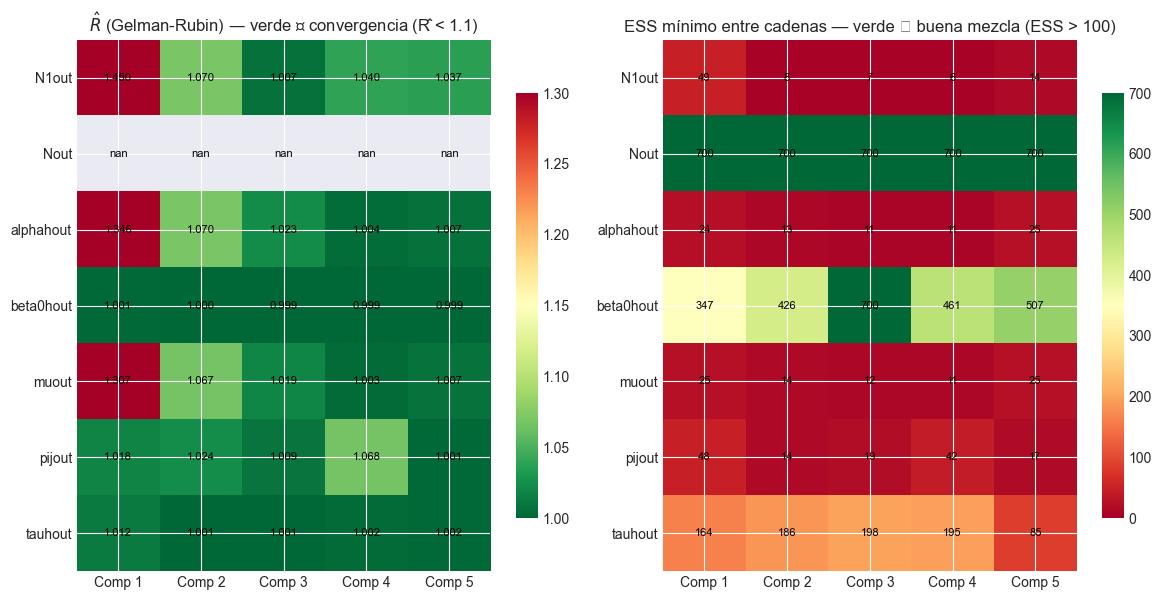

In [29]:
rhat_pivot = diag_df.pivot(index="param", columns="component", values="Rhat")
ess_pivot  = diag_df.pivot(index="param", columns="component", values="ESS_min")

fig, axes = plt.subplots(1, 2, figsize=(12, 4 + 0.3 * n_params))

# ── (a) R̂ ──
im0 = axes[0].imshow(rhat_pivot.values, aspect="auto", cmap="RdYlGn_r",
                     vmin=1.0, vmax=1.3)
axes[0].set_xticks(range(n_components))
axes[0].set_xticklabels([f"Comp {k+1}" for k in range(n_components)])
axes[0].set_yticks(range(len(rhat_pivot.index)))
axes[0].set_yticklabels(rhat_pivot.index)
axes[0].set_title(r"$\hat{R}$ (Gelman-Rubin) — verde ⇒ convergencia (R̂ < 1.1)")
for i in range(rhat_pivot.shape[0]):
    for j in range(rhat_pivot.shape[1]):
        val = rhat_pivot.values[i, j]
        axes[0].text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=8, color="black")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# ── (b) ESS ──
im1 = axes[1].imshow(ess_pivot.values, aspect="auto", cmap="RdYlGn",
                     vmin=0, vmax=ess_pivot.values.max())
axes[1].set_xticks(range(n_components))
axes[1].set_xticklabels([f"Comp {k+1}" for k in range(n_components)])
axes[1].set_yticks(range(len(ess_pivot.index)))
axes[1].set_yticklabels(ess_pivot.index)
axes[1].set_title("ESS mínimo entre cadenas — verde ⇒ buena mezcla (ESS > 100)")
for i in range(ess_pivot.shape[0]):
    for j in range(ess_pivot.shape[1]):
        val = ess_pivot.values[i, j]
        axes[1].text(j, i, f"{val:.0f}", ha="center", va="center",
                     fontsize=8, color="black")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# 8. Evaluación predictiva

Una vez verificada la convergencia, evaluamos el ajuste usando la primera cadena
(`c = 0`) — el resto se mantiene para diagnóstico, no para predicción. Esto es
estándar: con R̂ < 1.1 las cadenas convergieron a la misma distribución, así que
cualquiera de ellas sirve para inferencia.

In [30]:
eval_results = {}
inclusion_matrix = np.zeros((n_components, n_components * N_LAGS))
feature_names    = None

for k in range(n_components):
    m       = models_chains[k][0]
    in_rmse = m.rmse(dfs[k])
    in_pred = m.predict(dfs[k])
    y_obs   = dfs[k].iloc[:, 0].to_numpy()
    incl    = m.inclusion_probs(as_series=True)

    eval_results[k] = {
        "rmse":       in_rmse,
        "y_hat":      in_pred,
        "y_obs":      y_obs,
        "incl_vec":   incl.values,
        "incl_named": incl,
    }
    inclusion_matrix[k, :] = incl.values
    feature_names = list(incl.index)

    print(f"\nComponente {k+1}:  inRMSE = {in_rmse:.6f}")
    for name, val in incl.items():
        flag = " *" if val > 0.5 else "  "
        print(f"    P(γ=1 | {name:<20}) = {val:.4f}{flag}")


Componente 1:  inRMSE = 0.671977
    P(γ=1 | theta_1_lag1        ) = 1.0000 *
    P(γ=1 | theta_2_lag1        ) = 0.9957 *
    P(γ=1 | theta_3_lag1        ) = 0.0343  
    P(γ=1 | theta_4_lag1        ) = 0.0600  
    P(γ=1 | theta_5_lag1        ) = 0.0529  

Componente 2:  inRMSE = 1.803399
    P(γ=1 | theta_1_lag1        ) = 0.0857  
    P(γ=1 | theta_2_lag1        ) = 0.1886  
    P(γ=1 | theta_3_lag1        ) = 0.0914  
    P(γ=1 | theta_4_lag1        ) = 0.0643  
    P(γ=1 | theta_5_lag1        ) = 0.3300  

Componente 3:  inRMSE = 2.589064
    P(γ=1 | theta_1_lag1        ) = 0.2786  
    P(γ=1 | theta_2_lag1        ) = 0.0514  
    P(γ=1 | theta_3_lag1        ) = 0.0871  
    P(γ=1 | theta_4_lag1        ) = 0.0871  
    P(γ=1 | theta_5_lag1        ) = 0.0686  

Componente 4:  inRMSE = 2.064847
    P(γ=1 | theta_1_lag1        ) = 0.1571  
    P(γ=1 | theta_2_lag1        ) = 0.0914  
    P(γ=1 | theta_3_lag1        ) = 0.0829  
    P(γ=1 | theta_4_lag1        ) = 0.0857  
    P(γ=1

## 8.1 Scatter θ observado vs predicho

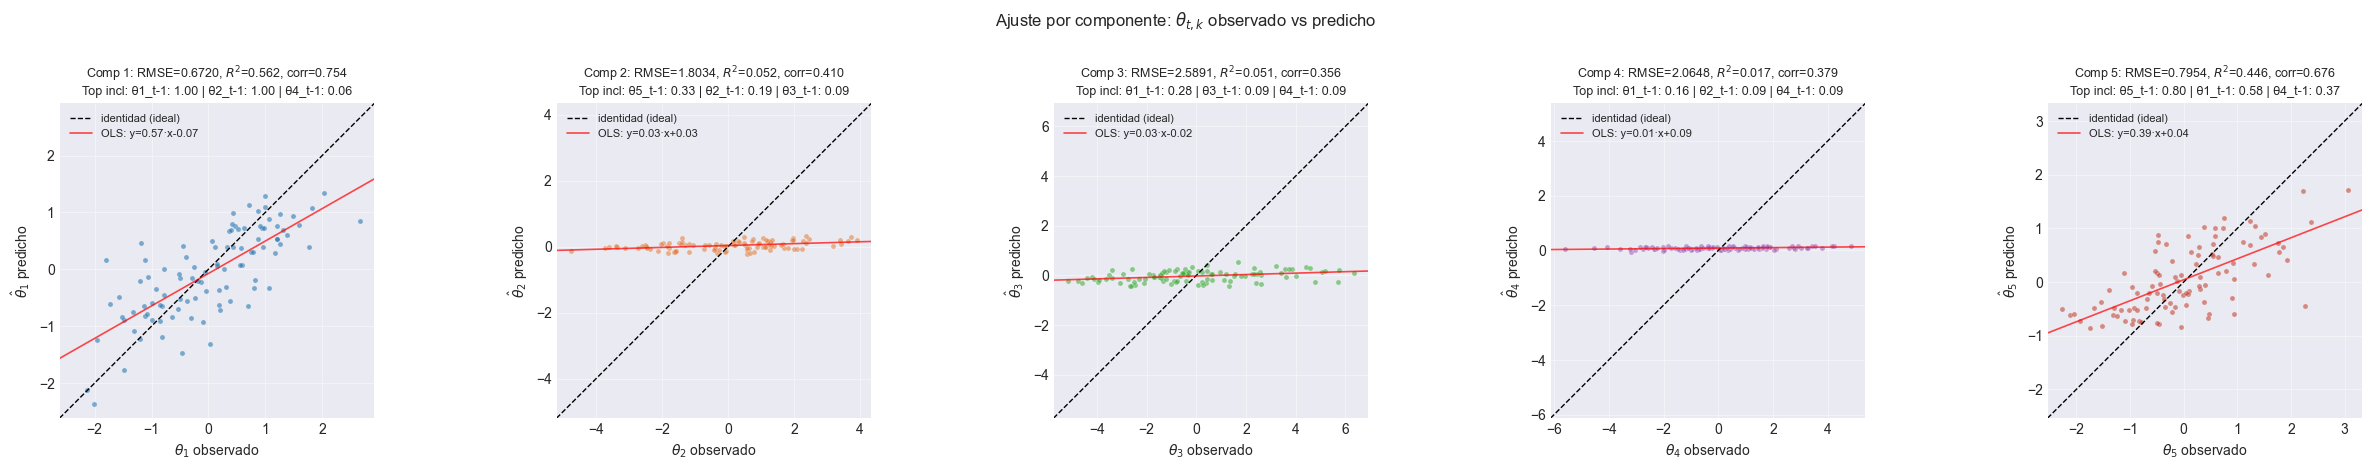

In [34]:
from scipy import stats as _stats

fig, axes = plt.subplots(1, n_components, figsize=(5 * n_components, 4.5))
component_colors = ["#1a6faf", "#e07b39", "#3aaa35", "#9b59b6", "#c0392b"]

# Asegura iterabilidad si n_components == 1
axes = np.atleast_1d(axes)

for k, ax in enumerate(axes):
    y_obs = eval_results[k]["y_obs"]
    y_hat = eval_results[k]["y_hat"]

    rmse   = eval_results[k]["rmse"]
    ss_res = np.sum((y_obs - y_hat) ** 2)
    ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
    r2     = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    corr   = np.corrcoef(y_obs, y_hat)[0, 1]
    slope, intercept, *_ = _stats.linregress(y_obs, y_hat)

    ax.scatter(y_obs, y_hat, s=14, alpha=0.55,
               color=component_colors[k % len(component_colors)],
               edgecolors="white", linewidths=0.3)

    lims = [min(y_obs.min(), y_hat.min()), max(y_obs.max(), y_hat.max())]
    pad  = 0.05 * (lims[1] - lims[0])
    lims = [lims[0] - pad, lims[1] + pad]
    ax.plot(lims, lims, "k--", lw=1.0, label="identidad (ideal)")

    xs = np.array(lims)
    ax.plot(xs, intercept + slope * xs, "r-", lw=1.2, alpha=0.7,
            label=f"OLS: y={slope:.2f}·x{intercept:+.2f}")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")

    incl = eval_results[k]["incl_named"]
    top3 = incl.sort_values(ascending=False).head(3)
    incl_str = " | ".join(
        f"{name.replace('theta_', 'θ').replace('_lag', '_t-')}: {val:.2f}"
        for name, val in top3.items()
    )

    ax.set_xlabel(rf"$\theta_{{{k+1}}}$ observado")
    ax.set_ylabel(rf"$\hat{{\theta}}_{{{k+1}}}$ predicho")
    ax.set_title(
        rf"Comp {k+1}: RMSE={rmse:.4f}, $R^2$={r2:.3f}, corr={corr:.3f}"
        f"\nTop incl: {incl_str}",
        fontsize=9,
    )
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.4)

plt.suptitle(
    r"Ajuste por componente: $\theta_{t,k}$ observado vs predicho",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## 8.2 Reconstrucción funcional

Verificación de inversión: max|X_recovered - X_raw| = 4.44e-16

── ESCALA ESTANDARIZADA ──
  RMSE representación : 0.502944
  RMSE modelo         : 0.630174
  RMSE total          : 0.804155
  Ratio modelo/total  : 0.784  (cuánto del error es atribuible al modelo)

── ESCALA ORIGINAL ──
  RMSE representación : 0.445483
  RMSE modelo         : 0.563395
  RMSE total          : 0.715013
  Ratio modelo/total  : 0.788  (cuánto del error es atribuible al modelo)

── Métricas adimensionales (NRMSE = RMSE / std(X̃)) ──
  Escala estandarizada: NRMSE_total = 0.810
  Escala original     : NRMSE_total = 0.678
  (ambos NRMSE deben ser similares si la inversión es correcta)


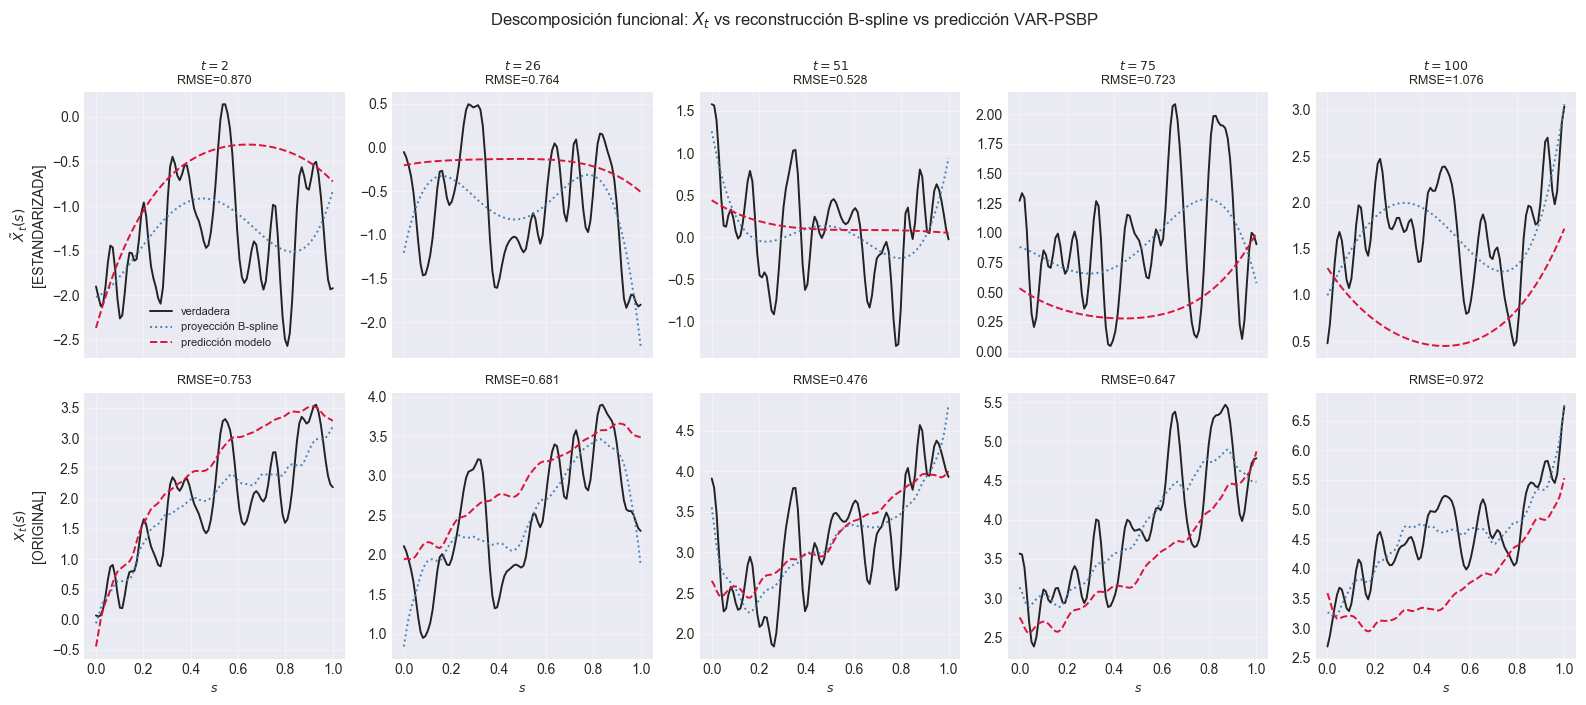

In [35]:
# ── Construcción de matrices de scores ──────────────────────────────────────
THETA_obs_mat  = np.column_stack([eval_results[k]["y_obs"]  for k in range(n_components)])
THETA_pred_mat = np.column_stack([eval_results[k]["y_hat"]  for k in range(n_components)])

# ── Reconstrucciones funcionales (escala ESTANDARIZADA) ─────────────────────
X_repr_obs_std  = fr.reconstruct(THETA_obs_mat)
X_repr_pred_std = fr.reconstruct(THETA_pred_mat)
X_true_std      = X[N_LAGS:, :]

# ── Inversión a escala ORIGINAL ─────────────────────────────────────────────
def inverse_zscore(X_std_arr):
    """Revierte z-score por columna usando X_mean, X_std guardados en sección 3."""
    return X_std_arr * X_std + X_mean

X_true_orig      = inverse_zscore(X_true_std)
X_repr_obs_orig  = inverse_zscore(X_repr_obs_std)
X_repr_pred_orig = inverse_zscore(X_repr_pred_std)

# ── Verificación ─────────────────────────────────────────────────────────────
recovery_err = np.max(np.abs(X_true_orig - X_raw[N_LAGS:, :]))
print(f"Verificación de inversión: max|X_recovered - X_raw| = {recovery_err:.2e}")
assert recovery_err < 1e-10, "La inversión z-score no es exacta — revisar X_mean/X_std"

# ── Métricas por escala ─────────────────────────────────────────────────────
def rmse_decomposition(true, repr_obs, repr_pred, label):
    err_repr  = true     - repr_obs
    err_model = repr_obs - repr_pred
    err_total = true     - repr_pred
    rmse_r = np.sqrt(np.mean(err_repr  ** 2))
    rmse_m = np.sqrt(np.mean(err_model ** 2))
    rmse_t = np.sqrt(np.mean(err_total ** 2))
    print(f"\n── {label} ──")
    print(f"  RMSE representación : {rmse_r:.6f}")
    print(f"  RMSE modelo         : {rmse_m:.6f}")
    print(f"  RMSE total          : {rmse_t:.6f}")
    print(f"  Ratio modelo/total  : {rmse_m/rmse_t:.3f}  "
          f"(cuánto del error es atribuible al modelo)")
    return rmse_r, rmse_m, rmse_t

m_std  = rmse_decomposition(X_true_std,  X_repr_obs_std,  X_repr_pred_std,  "ESCALA ESTANDARIZADA")
m_orig = rmse_decomposition(X_true_orig, X_repr_obs_orig, X_repr_pred_orig, "ESCALA ORIGINAL")

print(f"\n── Métricas adimensionales (NRMSE = RMSE / std(X̃)) ──")
sd_std  = X_true_std.std()
sd_orig = X_true_orig.std()
print(f"  Escala estandarizada: NRMSE_total = {m_std[2]/sd_std:.3f}")
print(f"  Escala original     : NRMSE_total = {m_orig[2]/sd_orig:.3f}")
print(f"  (ambos NRMSE deben ser similares si la inversión es correcta)")

# ── Visualización ────────────────────────────────────────────────────────────
N_SNAPSHOTS = 5
T_eff       = X_true_std.shape[0]
t_indices   = np.linspace(0, T_eff - 1, N_SNAPSHOTS, dtype=int)

fig, axes = plt.subplots(2, N_SNAPSHOTS, figsize=(3.2 * N_SNAPSHOTS, 7), sharex=True)
fig.suptitle(
    r"Descomposición funcional: $X_t$ vs reconstrucción B-spline vs predicción VAR-PSBP",
    fontsize=12, y=1.00,
)

rows = [
    ("ESTANDARIZADA", X_true_std,  X_repr_obs_std,  X_repr_pred_std,  r"$\tilde X_t(s)$"),
    ("ORIGINAL",      X_true_orig, X_repr_obs_orig, X_repr_pred_orig, r"$X_t(s)$"),
]

for row_idx, (scale_name, X_t, X_r, X_p, ylbl) in enumerate(rows):
    for col_idx, t_idx in enumerate(t_indices):
        ax = axes[row_idx, col_idx]
        t_real = t_idx + N_LAGS + 1

        ax.plot(domain.grid, X_t[t_idx], color="black",     lw=1.4,
                alpha=0.85, label="verdadera"          if col_idx == 0 else None)
        ax.plot(domain.grid, X_r[t_idx], color="steelblue", lw=1.4, ls=":",
                label="proyección B-spline"            if col_idx == 0 else None)
        ax.plot(domain.grid, X_p[t_idx], color="crimson",   lw=1.4, ls="--",
                label="predicción modelo"              if col_idx == 0 else None)

        rmse_local = np.sqrt(np.mean((X_t[t_idx] - X_p[t_idx]) ** 2))
        if row_idx == 0:
            ax.set_title(f"$t = {t_real}$\nRMSE={rmse_local:.3f}", fontsize=9)
        else:
            ax.set_title(f"RMSE={rmse_local:.3f}", fontsize=9)

        if col_idx == 0:
            ax.set_ylabel(f"{ylbl}\n[{scale_name}]", fontsize=10)
        if row_idx == 1:
            ax.set_xlabel("$s$", fontsize=9)
        ax.grid(True, alpha=0.35)

axes[0, 0].legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

# 9. Persistencia de resultados

In [36]:
PATHS["predict"].mkdir(parents=True, exist_ok=True)
(PATHS["reports"] / EXPERIMENT_ID).mkdir(parents=True, exist_ok=True)
report_dir = PATHS["reports"] / EXPERIMENT_ID

# ── 9.1 Scores y datos → .npz ───────────────────────────────────────────────
path_scores = PATHS["predict"] / f"{EXPERIMENT_ID}_scores.npz"
np.savez_compressed(
    path_scores,
    THETA       = THETA,
    THETA_obs   = THETA_obs_mat,
    THETA_pred  = THETA_pred_mat,
    X_raw       = X_raw,
    X_std       = X,
    X_mean_col  = X_mean,
    X_std_col   = X_std,
)
print(f"[OK] Scores → {path_scores.relative_to(PROJECT_ROOT)}")

# ── 9.2 Trazas: todas las cadenas para todos los componentes ─────────────────
for k in range(n_components):
    for c in range(N_CHAINS):
        path_t = PATHS["predict"] / f"{EXPERIMENT_ID}_traces_comp{k+1}_chain{c+1}.npz"
        np.savez_compressed(path_t, **models_chains[k][c].traces)
print(f"[OK] Trazas multi-cadena → {PATHS['predict'].relative_to(PROJECT_ROOT)}")

# ── 9.3 Tabla de diagnósticos → .csv ─────────────────────────────────────────
path_diag = report_dir / f"{EXPERIMENT_ID}_diagnostics.csv"
diag_df.to_csv(path_diag, index=False)
print(f"[OK] Tabla diagnósticos → {path_diag.relative_to(PROJECT_ROOT)}")

# ── 9.4 Metadatos del experimento → .json ────────────────────────────────────
metadata = {
    "experiment_id":   EXPERIMENT_ID,
    "timestamp":       TIMESTAMP,
    "seed_base":       SEED,
    "chain_seeds":     CHAIN_SEEDS,
    "n_chains":        N_CHAINS,
    "n_components":    n_components,
    "far_params":      FAR_PARAMS,
    "standarize":      STANDARIZE_CONFIG,
    "repre_params":    REPRE_PARAMS,
    "mcmc_config":     MCMC_CONFIG,
    "hyperparams":     HYPERPARAMS,
    "var_retained":    float(var_retained),   # escalar; era evr.tolist() con FPCA
}
path_meta = report_dir / f"{EXPERIMENT_ID}_metadata.json"
with open(path_meta, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"[OK] Metadatos       → {path_meta.relative_to(PROJECT_ROOT)}")

[OK] Scores → data\simulaciones\processed\predict\convergencia_FAR_lineal_st_2_1_20260512_005512_scores.npz
[OK] Trazas multi-cadena → data\simulaciones\processed\predict
[OK] Tabla diagnósticos → reports\simulaciones\convergencia_FAR_lineal_st_2_1_20260512_005512\convergencia_FAR_lineal_st_2_1_20260512_005512_diagnostics.csv
[OK] Metadatos       → reports\simulaciones\convergencia_FAR_lineal_st_2_1_20260512_005512\convergencia_FAR_lineal_st_2_1_20260512_005512_metadata.json
